In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
PROJECT_ROOT = os.path.abspath(".")
pd.set_option("display.width", 140)
pd.set_option("display.max_columns", None)

## Part 2 - Sender-level structure, features, models, explanations and reports

Part 1 looked at the data message by message. Everything from here on follows the rest of the data science lifecycle:

| Step | Question | Result |
|---|---|---|
| 1 | What does the data look like per vehicle, and how do we know which class is which? | class table, class signatures |
| 2 | How do we split the data so the test score is honest? | vehicle-level split, leakage demo |
| 3 | Which features can separate the classes? | 41 features (F0, F1, F2) |
| 4 | Which model, and how sure are we? | 20 experiments, final XGBoost model |
| 5 | How good is the final model, and where does it fail? | metrics with confidence intervals, error analysis |
| 6 | Why does the model predict what it predicts? | SHAP |
| 7 | How do we turn the explanation into a report? | evidence package, report writer |
| 8 | Can we trust the reports? | automatic faithfulness checks |
| 9 | How do we show it? | Streamlit app |

How this part is written: each step is done here first with plain pandas / scikit-learn code, and then compared with the helper
function in `src/veremi_xai/` that the scripts and the app use. Long runs (the 20 experiments took about 1.5 hours) are **not**
repeated in the notebook; their saved results are loaded from `outputs/results/`. Small live runs show how each step works.

In [2]:
import sys, json, glob, subprocess
from IPython.display import Image, Markdown, display

os.chdir(PROJECT_ROOT)                                   # PROJECT_ROOT comes from the first cell of this notebook
sys.path.insert(0, os.path.join(PROJECT_ROOT, "src"))

from veremi_xai import evaluate as evl
from veremi_xai.config import RAW_FEATURES, class_names, load_config, path
from veremi_xai.data import build_parquet, make_sender_split
from veremi_xai.features import F0, F1, F2, CONTEXT, DESCRIPTIONS, RoadMap, add_features
from veremi_xai.models import make_model
from veremi_xai.pipeline import Pipeline
from veremi_xai.reporting import generate_report
from veremi_xai.reporting.prompts import SYSTEM
from veremi_xai.reporting.validator import validate
from veremi_xai.viz import style as chart_style

chart_style()
CLASSES = load_config()["classes"]
NAMES = class_names()
RESULTS_DIR = str(path("results"))
FIGURE_DIR = str(path("figures"))

def show_fig(name, width=None):
    display(Image(filename=os.path.join(FIGURE_DIR, name), width=width))

# the scripts 01 and 01b create the Parquet copy, the split and the feature tables (about 3 minutes, only if they are missing)
needed = [path("parquet"), path("split"), path("features").with_name("features_senderPseudo.parquet"), path("features").with_name("road_dist.parquet")]
if not all(p.exists() for p in needed):
    for script in ("scripts/01_prepare_data.py", "scripts/01b_road_feature.py"):
        subprocess.run([sys.executable, script], check=True)
print("artifacts ready")

artifacts ready


### Step 1 - The data per vehicle

The label belongs to a **vehicle**, not to a single message. We keep only the 21 useful columns (the constant `type` and the eight z-columns are dropped)
and sort the messages by vehicle and time. `build_parquet()` reads the 1.2 GB csv once and saves a compact Parquet copy.

In [3]:
msgs = build_parquet()
print(msgs.shape)
per_vehicle = msgs.groupby("sender").agg(cls=("class", "first"), n_classes=("class", "nunique"),
                                         messages=("class", "size"), pseudonyms=("senderPseudo", "nunique"))
print("vehicles:", len(per_vehicle))
print("vehicles that appear with more than one class:", int((per_vehicle.n_classes > 1).sum()))
overview = per_vehicle.groupby("cls").agg(vehicles=("messages", "size"), median_messages=("messages", "median"),
                                          median_pseudonyms=("pseudonyms", "median"))
overview.insert(0, "name", [NAMES[c] for c in overview.index])
display(overview)

(3194808, 21)


vehicles: 24663
vehicles that appear with more than one class: 0


,name,vehicles,median_messages,median_pseudonyms
cls,,,,
0,Genuine,17264,109.0,1.0
1,Constant position,390,110.5,1.0
2,Constant position offset,390,111.0,1.0
3,Random position,390,112.0,1.0
4,Random position offset,389,104.0,1.0
5,Constant speed,390,101.5,1.0
6,Constant speed offset,389,116.0,1.0
7,Random speed,389,107.0,1.0
8,Random speed offset,389,106.0,1.0


Every vehicle has exactly one class, and every attack class has about 390 vehicles. The row counts of the classes differ only because some classes
send messages faster (next cell). Vehicles of class 17, 18 and 19 use up to 100 different pseudonyms.

### How do we know which class is which?

The csv only contains the numbers 0 to 19. The names come from the simulator that generated the data (F2MD, source file `AttackTypes.h`),
and we checked them against the data. One paper (Khan et al. 2025, Table 2) uses a different order of names for the same csv, and that order does
**not** fit the data (for example its "Eventual stop" never stops). The four checks below use the definitions of the dataset paper.

In [4]:
msgs["dt"] = msgs.sendTime.diff().where(msgs.sender.eq(msgs.sender.shift()))      # msgs is sorted by vehicle and time
msgs["spd"] = np.hypot(msgs.spdx, msgs.spdy)

signature = pd.DataFrame({
    "median seconds between messages": msgs.groupby("class").dt.median(),
    "speed std inside one vehicle": msgs.groupby(["class", "sender"]).spd.std().groupby("class").median(),
    "share of messages with speed 0": msgs.groupby("class").spd.apply(lambda s: (s == 0).mean()),
    "median pseudonyms per vehicle": per_vehicle.groupby("cls").pseudonyms.median(),
})
signature.insert(0, "name", [NAMES[c] for c in signature.index])
display(signature.round(3))

zero = (msgs[["posx", "posy", "spdx", "spdy"]] == 0).all(axis=1)
c12 = msgs[msgs["class"] == 12].assign(zero=zero)
lead = c12.groupby("sender").zero.apply(lambda s: int(s.to_numpy().argmin()) if (~s).any() else len(s))
print("class 12: all-zero messages at the start of a vehicle:", int(lead.median()), "(median);  all-zero messages anywhere else:", int(c12.zero.sum() - lead.sum()))

,name,median seconds between messages,speed std inside one vehicle,share of messages with speed 0,median pseudonyms per vehicle
0,Genuine,1.000,4.186,0.002,1.0
1,Constant position,1.000,4.245,0.001,1.0
2,Constant position offset,1.000,4.104,0.001,1.0
3,Random position,1.000,4.257,0.002,1.0
4,Random position offset,1.000,4.212,0.001,1.0
5,Constant speed,1.000,0.000,0.000,1.0
6,Constant speed offset,1.000,4.353,0.000,1.0
7,Random speed,1.000,11.361,0.000,1.0
8,Random speed offset,1.000,6.280,0.000,1.0
9,Eventual stop,1.000,3.409,0.809,1.0


class 12: all-zero messages at the start of a vehicle: 61 (median);  all-zero messages anywhere else: 0


What the numbers say (each line is one class of the table above):

- **DoS family (13, 14, 15)** send every 0.25 s instead of every 1 s. The F2MD default is a factor of 4. Sybil versions of DoS (18, 19) send every 0.5 s (factor 2).
- **Constant speed (5)**: the speed of a vehicle never changes (standard deviation 0.000).
- **Eventual stop (9)**: 81 % of the messages have speed 0 (the vehicle has stopped).
- **Sybil classes (16 to 19)** use many pseudonyms per vehicle; Grid Sybil (16) sends every 0.167 s (6 identities).
- **Delayed messages (12)**: every vehicle starts with about 60 all-zero messages, which matches the buffer of 60 messages in the simulator.

The full table with all measurements (and the class definitions that the report writer is allowed to use) was made by `scripts/09_paper_tables.py`:

,class_id,name,group,messages,share_of_messages_%,vehicles,median_seconds_between_messages,median_pseudonyms_per_vehicle,mean_speed_m_per_s,share_speed_zero_%,share_identical_to_another_message_%,share_copy_of_a_genuine_message_%
0,0,Genuine,genuine,1900539,59.49,17264,1.000,1.0,9.71,0.2,6.7,0.0
1,1,Constant position,fault,43653,1.37,390,1.000,1.0,9.73,0.1,9.3,0.0
2,2,Constant position offset,fault,43567,1.36,390,1.000,1.0,9.82,0.1,3.7,0.0
3,3,Random position,fault,43857,1.37,390,1.000,1.0,9.55,0.2,3.9,0.0
4,4,Random position offset,fault,42575,1.33,389,1.000,1.0,9.65,0.1,6.9,0.0
5,5,Constant speed,fault,41925,1.31,390,1.000,1.0,31.08,0.0,5.2,0.0
6,6,Constant speed offset,fault,44359,1.39,389,1.000,1.0,13.63,0.0,6.8,0.0
7,7,Random speed,fault,42258,1.32,389,1.000,1.0,30.62,0.0,5.9,0.0
8,8,Random speed offset,fault,42583,1.33,389,1.000,1.0,13.72,0.0,6.9,0.0
9,9,Eventual stop,attack,42790,1.34,389,1.000,1.0,1.84,80.9,82.4,0.0


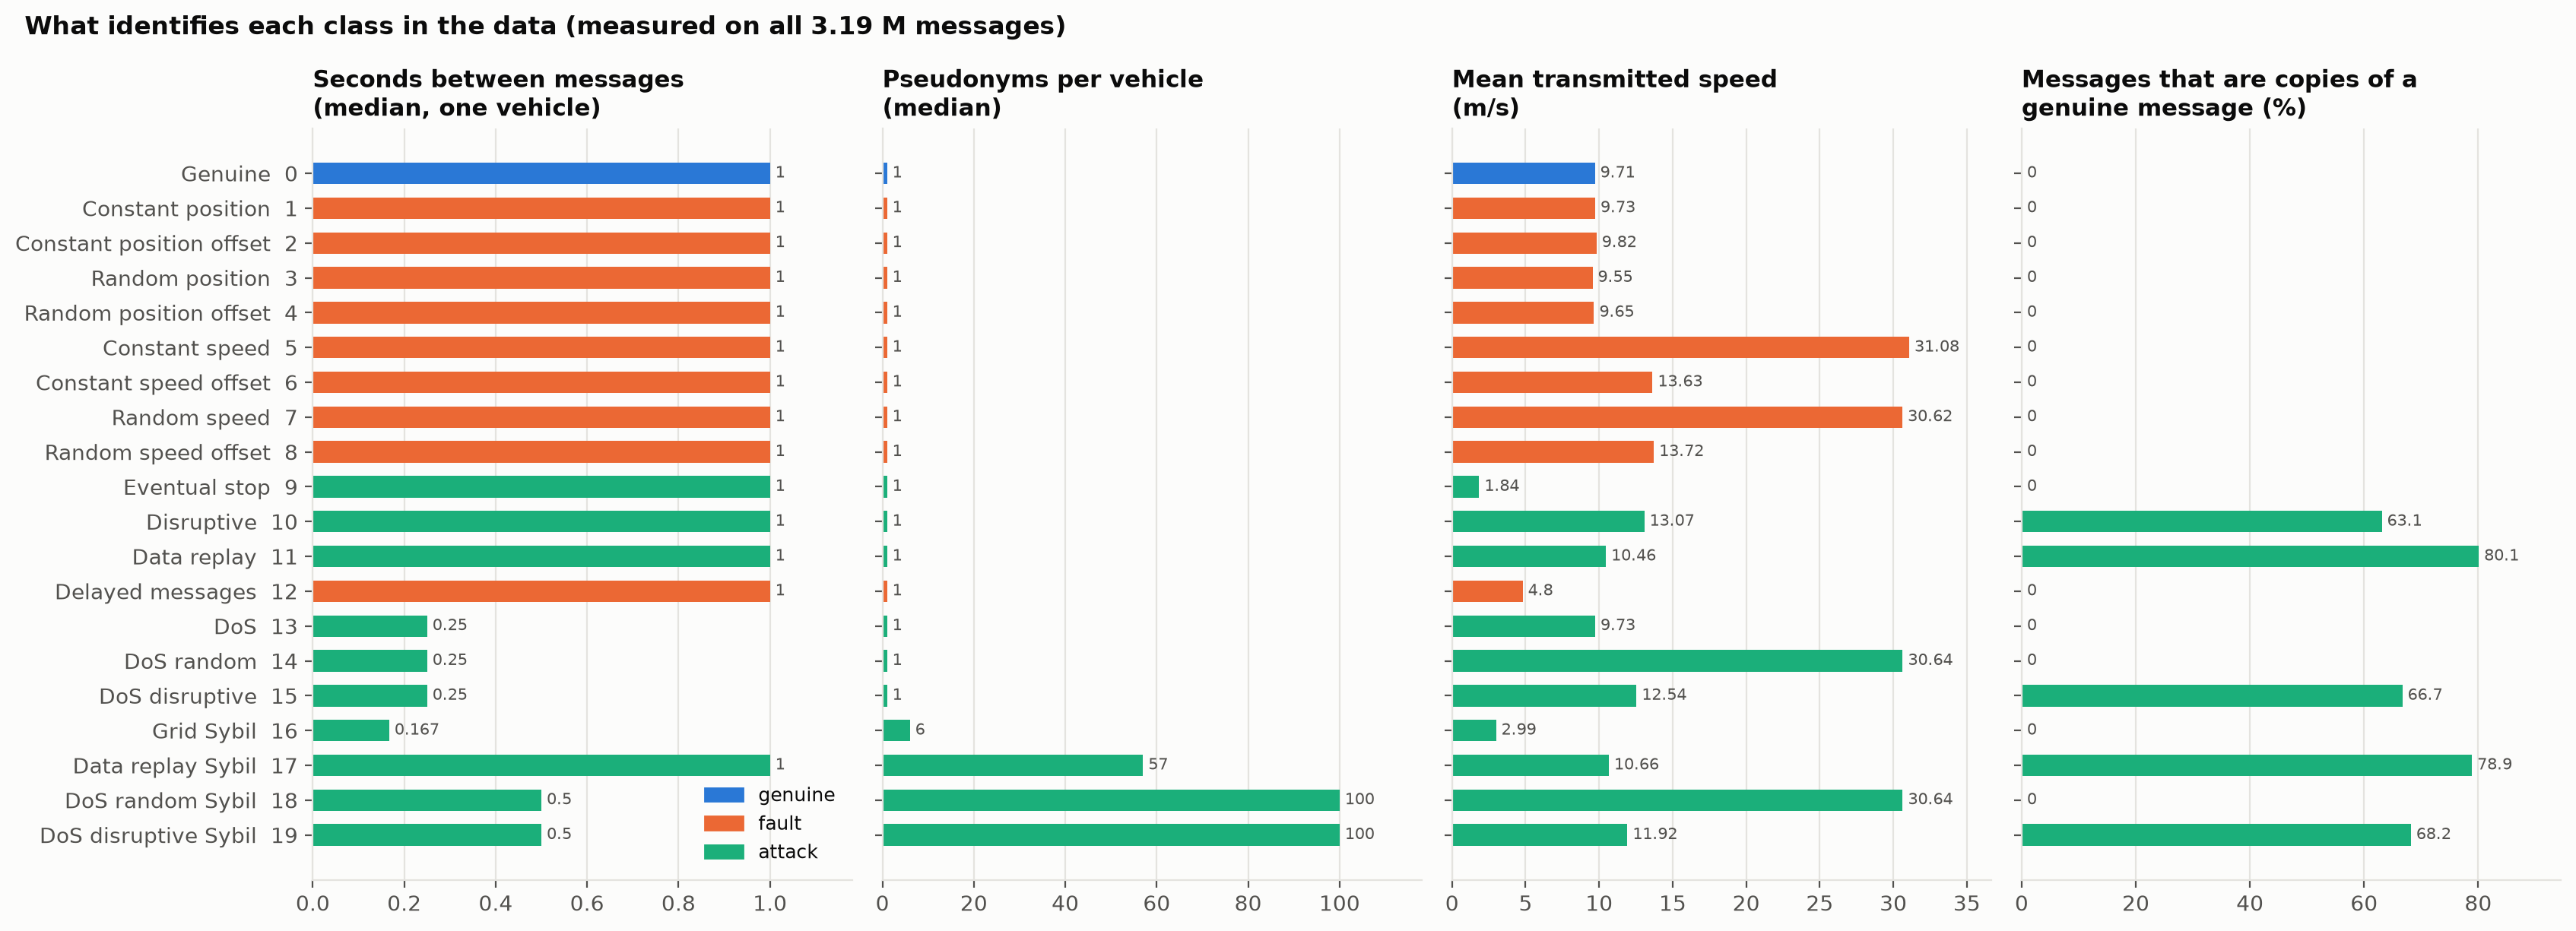

In [5]:
t1 = pd.read_csv(f"{RESULTS_DIR}/paper_tables/T1_dataset_classes.csv")
display(t1.drop(columns=["definition"]))
show_fig("class_signatures.png")

Another important finding is in the last two columns of the table: for the classes 10, 11, 13, 15, 17 and 19 almost **all** messages are exact copies of
some other message in the data, often of a genuine one. A single message of these classes cannot be told apart from a genuine message. The model can only
recognise them from the behaviour of the vehicle over time (how often it sends, how many pseudonyms it uses, whether speed and position agree).
That is the reason for the history features in Step 3.

### Step 2 - Splitting the data so that the test score is honest

Because a vehicle has one label and its messages are almost identical, a random split of the **rows** would put messages of the same vehicle into train and test.
The model could then remember the vehicle. We split the **vehicles** instead: 70 % train, 15 % validation, 15 % test, separately for each class.

In [6]:
split = make_sender_split(msgs)                                    # the official split, saved once in artifacts/sender_split.csv
msgs["split"] = msgs.sender.map(split.set_index("sender")["split"])
print("every vehicle is in exactly one partition:", bool((msgs.groupby("sender").split.nunique() == 1).all()))
table = msgs.groupby(["class", "split"]).sender.nunique().unstack()[["train", "val", "test"]]
table.insert(0, "name", [NAMES[c] for c in table.index])
display(table)
print(msgs.groupby("split").size())

every vehicle is in exactly one partition: True


split,name,train,val,test
class,,,,
0,Genuine,12085,2590,2589
1,Constant position,273,58,59
2,Constant position offset,273,58,59
3,Random position,273,58,59
4,Random position offset,272,58,59
5,Constant speed,273,58,59
6,Constant speed offset,272,58,59
7,Random speed,272,58,59
8,Random speed offset,272,58,59


split
test      478186
train    2235009
val       481613
dtype: int64


**How big is the leakage effect?** A small live experiment: the same model on the same features (the 18 per-message features only), once with a random split
of the rows and once with the vehicle split. Only 300 000 messages are used to keep it fast, so the numbers differ from the full runs (0.680 and 0.369 in the table
of Step 4), but the effect is the same.

In [7]:
feat_file = path("features").with_name("features_senderPseudo.parquet")
feat0 = pd.read_parquet(feat_file, columns=F0 + ["sender", "class", "split"])
sub = feat0.sample(300_000, random_state=42)
del feat0

def fit_and_score(train, test):
    model = make_model("xgb", 42, n_estimators=150, learning_rate=0.2, max_depth=8, early_stopping_rounds=None)
    model.fit(train[F0], train["class"])
    return evl.summary_metrics(test["class"], model.predict(test[F0]))

order = np.random.default_rng(42).permutation(len(sub))
a, b = int(0.70 * len(sub)), int(0.85 * len(sub))
by_row = fit_and_score(sub.iloc[order[:a]], sub.iloc[order[b:]])
by_vehicle = fit_and_score(sub[sub.split == "train"], sub[sub.split == "test"])
demo_leak = pd.DataFrame({"random split of rows": by_row, "split by vehicle": by_vehicle}).loc[["macro_f1", "balanced_accuracy", "accuracy"]]
display(demo_leak.round(3))
del sub

<venv>\Lib\site-packages\xgboost\core.py:569: UserWarning: [01:00:52] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\common\error_msg.cc:62: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  return func(**kwargs)


,random split of rows,split by vehicle
macro_f1,0.488,0.371
balanced_accuracy,0.456,0.351
accuracy,0.767,0.731


With the random split the model looks much better than it really is, because it has seen the same vehicles during training. **All results in this notebook use the vehicle split.**

### Step 3 - Feature engineering

The 16 raw values of a message (position, speed, acceleration, heading and their noise values) plus speed and acceleration magnitude are called **F0** (18 features).
As Step 1 showed, F0 alone is not enough. A receiver can also remember earlier messages that it received under the same pseudonym.
We add 22 **history features** (**F1**). They use only the current and earlier messages, never later ones. Then we add one map feature (**F2**).

**Example: two vehicles by hand.** The time between messages `dt`, the distance between positions `dpos`, the speed that the positions imply
`v_implied = dpos / dt`, and the disagreement `spd_resid = speed - v_implied`. A DoS vehicle sends every 0.25 s; in a genuine vehicle position and speed agree.

In [8]:
train_rows = msgs[msgs.split == "train"]
dos_pid = train_rows[train_rows["class"] == 13].senderPseudo.iloc[0]
gen_pid = train_rows[train_rows["class"] == 0].senderPseudo.iloc[0]

def by_hand(pid, n=8):
    v = msgs[msgs.senderPseudo == pid].sort_values("sendTime").head(n)[["sendTime", "posx", "posy", "spdx", "spdy"]].copy()
    v["dt"] = v.sendTime.diff()
    v["dpos"] = np.hypot(v.posx.diff(), v.posy.diff())
    v["v_implied"] = v.dpos / v.dt
    v["spd"] = np.hypot(v.spdx, v.spdy)
    v["spd_resid"] = v.spd - v.v_implied
    return v

print("DoS vehicle:")
display(by_hand(dos_pid).round(3))
print("genuine vehicle:")
display(by_hand(gen_pid).round(3))

# the helper function used by the scripts and the app gives the same numbers
cols = ["dt", "dpos", "v_implied", "spd_resid"]
helper = add_features(msgs[msgs.senderPseudo == dos_pid]).sort_values("sendTime").head(8)[cols]
print("helper add_features() equals the hand calculation:", bool(np.allclose(by_hand(dos_pid)[cols].iloc[1:].to_numpy(), helper.iloc[1:].to_numpy())))

DoS vehicle:


,sendTime,posx,posy,spdx,spdy,dt,dpos,v_implied,spd,spd_resid
2423,1538.877,793.138,753.509,-2.034,-0.493,NaN,NaN,NaN,2.093,NaN
2424,1539.377,790.700,753.445,-4.016,-0.407,0.5,2.439,4.878,4.037,-0.841
2425,1539.877,790.700,753.445,-4.016,-0.407,0.5,0.000,0.000,4.037,4.037
2426,1540.377,785.865,754.445,-5.869,1.222,0.5,4.937,9.875,5.995,-3.879
2427,1540.877,785.865,754.445,-5.869,1.222,0.5,0.000,0.000,5.995,5.995
2428,1541.377,779.765,758.038,-6.621,4.421,0.5,7.079,14.158,7.961,-6.197
2429,1541.877,779.765,758.038,-6.621,4.421,0.5,0.000,0.000,7.961,7.961
2430,1542.377,774.225,765.103,-5.453,8.297,0.5,8.978,17.956,9.928,-8.028


genuine vehicle:


,sendTime,posx,posy,spdx,spdy,dt,dpos,v_implied,spd,spd_resid
0,240.603,265.105,50.751,-0.107,1.034,NaN,NaN,NaN,1.040,NaN
1,241.603,264.960,53.058,-0.335,3.246,1.0,2.311,2.311,3.264,0.952
2,242.603,264.331,57.302,-0.604,5.324,1.0,4.290,4.290,5.358,1.068
3,243.603,263.611,63.710,-0.999,7.184,1.0,6.448,6.448,7.253,0.805
4,244.603,262.622,71.941,-1.409,9.106,1.0,8.290,8.290,9.214,0.924
5,245.603,261.037,82.188,-1.564,11.241,1.0,10.369,10.369,11.350,0.981
6,246.603,259.001,94.556,-2.415,13.369,1.0,12.534,12.534,13.585,1.051
7,247.603,256.894,108.720,-2.321,14.325,1.0,14.320,14.320,14.512,0.192


helper add_features() equals the hand calculation: True


The other history features are rolling statistics over the last 10 messages of the pseudonym (mean gap, mean position jump, spread of speed, mean and spread of the
speed-vs-position disagreement, mean and spread of the velocity error, share of repeated messages) and a few more comparisons between consecutive messages
(acceleration vs speed change, heading vs direction of travel, change of heading, identical-to-previous flag, message counter).

**A feature must not look into the future.** We test it: compute the features once on all messages of 30 pseudonyms, and once after removing the second half of their messages.
For the messages that remain, the values must be identical.

In [9]:
some = msgs[msgs.senderPseudo.isin(msgs.senderPseudo.drop_duplicates().sample(30, random_state=1))]
full = add_features(some)
half = some[some.groupby("senderPseudo").cumcount() < some.groupby("senderPseudo").senderPseudo.transform("size") / 2]
part = add_features(half)
same = np.allclose(full.set_index("messageID").loc[part.messageID, F1].to_numpy(float), part[F1].to_numpy(float), equal_nan=True, atol=1e-5)
print("features of earlier messages do not change when later messages are removed:", same)
display(pd.DataFrame({"feature": CONTEXT, "meaning": [DESCRIPTIONS[c] for c in CONTEXT]}))

features of earlier messages do not change when later messages are removed: True


,feature,meaning
0,dt,time since the previous message of the same id...
1,dpos,distance between this and the previous transmi...
2,v_implied,speed implied by the change in transmitted pos...
3,spd_resid,transmitted speed minus position-implied speed...
4,vel_err_x,transmitted X speed minus position-implied X v...
5,vel_err_y,transmitted Y speed minus position-implied Y v...
6,acl_err_x,transmitted X acceleration minus speed-implied...
7,acl_err_y,transmitted Y acceleration minus speed-implied...
8,hed_disp_cos,cosine between transmitted heading and directi...
9,dhed,change of heading since the previous message (...


**The road map (F2).** Genuine vehicles drive on roads. From the positions of genuine **training** vehicles we mark every 5 m x 5 m cell that was ever visited.
`road_dist` is the distance from a message position to the nearest visited cell. The map is learned on training data only, like a scaler.
It helps against the fault "constant position offset" (class 2), whose messages have correct kinematics but a shifted position.

6437 cells of 5 m were visited by genuine training vehicles


,name,share of test messages more than 5 m from the road map
class,,
0,Genuine,0.000
1,Constant position,0.914
2,Constant position offset,0.802
3,Random position,0.904
4,Random position offset,0.570
5,Constant speed,0.000
6,Constant speed offset,0.000
7,Random speed,0.000
8,Random speed offset,0.000


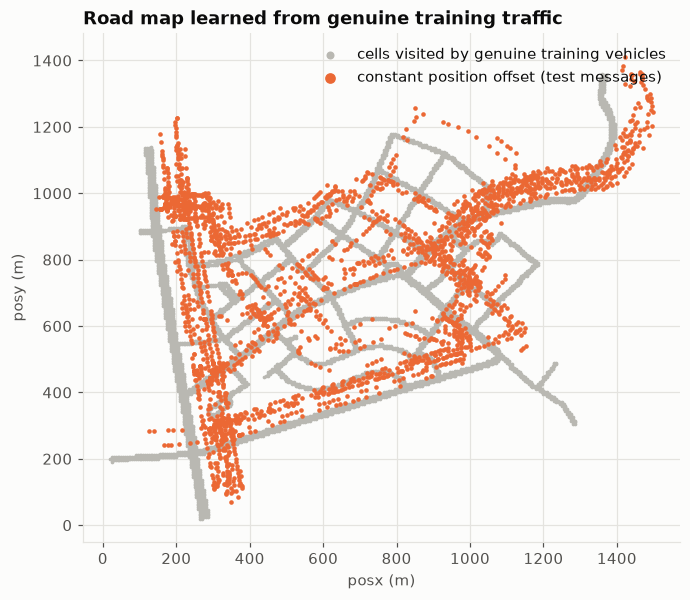

In [10]:
genuine_train = msgs[(msgs.split == "train") & (msgs["class"] == 0)]
road = RoadMap.fit(genuine_train)
print(len(road.cells), "cells of 5 m were visited by genuine training vehicles")

msgs["road_dist"] = pd.read_parquet(path("features").with_name("road_dist.parquet"))["road_dist"].to_numpy()
test_msgs = msgs[msgs.split == "test"]
off_map = (test_msgs.road_dist > 5).groupby(test_msgs["class"]).mean()
display(pd.DataFrame({"name": [NAMES[c] for c in off_map.index], "share of test messages more than 5 m from the road map": off_map.round(3).values}, index=off_map.index))

pts = test_msgs[test_msgs["class"] == 2].sample(3000, random_state=0)
fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(road.cells[:, 0] * 5, road.cells[:, 1] * 5, s=2, color="#b9b8b2", label="cells visited by genuine training vehicles")
ax.scatter(pts.posx, pts.posy, s=4, color="#eb6834", label="constant position offset (test messages)")
ax.set_xlabel("posx (m)"); ax.set_ylabel("posy (m)"); ax.legend(loc="upper right", markerscale=3); ax.set_title("Road map learned from genuine training traffic")
fig.savefig(os.path.join(FIGURE_DIR, "road_map.png")); plt.show()

**Do the features separate the classes?** Three of the most useful features for the 20 classes (test messages, 200 000 sample). The y axes are log-like.

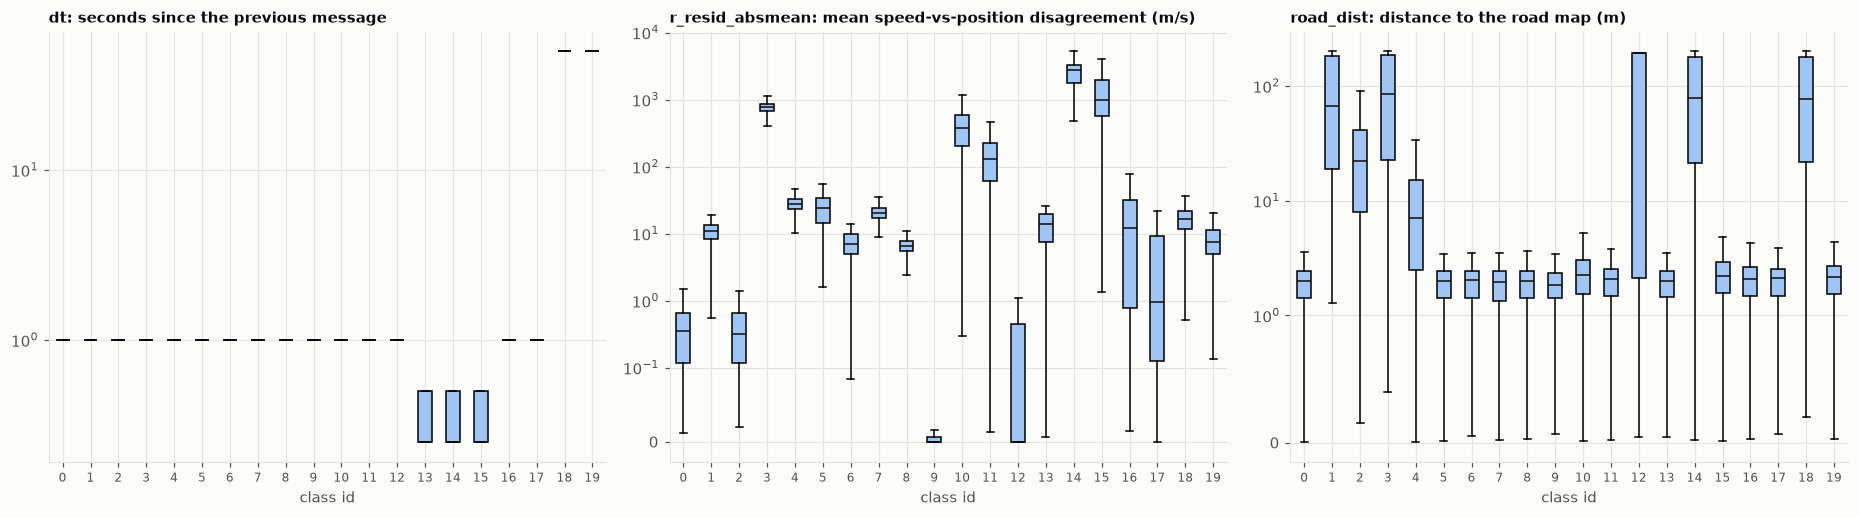

In [11]:
fcols = ["dt", "r_resid_absmean", "class"]
fx = pd.read_parquet(feat_file, columns=fcols + ["split"]); fx = fx[fx.split == "test"].sample(200_000, random_state=0)
fx["road_dist"] = msgs.loc[fx.index, "road_dist"]
fig, axes = plt.subplots(1, 3, figsize=(17, 4.8))
for ax, col, ttl, lin in zip(axes, ["dt", "r_resid_absmean", "road_dist"],
                             ["dt: seconds since the previous message", "r_resid_absmean: mean speed-vs-position disagreement (m/s)", "road_dist: distance to the road map (m)"], [0.1, 0.1, 1]):
    data = [fx.loc[fx["class"] == c, col].dropna().to_numpy() for c in range(20)]
    ax.boxplot(data, showfliers=False, patch_artist=True, boxprops=dict(facecolor="#9ec5f4"), medianprops=dict(color="#0b0b0b"))
    ax.set_yscale("symlog", linthresh=lin); ax.set_xticks(range(1, 21), range(20), fontsize=8); ax.set_xlabel("class id"); ax.set_title(ttl, fontsize=10)
fig.tight_layout(); fig.savefig(os.path.join(FIGURE_DIR, "feature_distributions.png")); plt.show()

Each feature separates a different group of classes: `dt` finds the DoS family, the speed-vs-position disagreement finds the random position and speed faults
and the replay classes, and `road_dist` finds position faults. The complete list of the 41 features with their meaning is in `paper_tables/T3_feature_dictionary.csv`.

### Step 4 - Models

**Live demo of the training step.** XGBoost on a 300 000-message sample of the training vehicles, validated on 100 000 messages of the validation vehicles.
The curve is the validation loss; training stops when it does not improve for 30 rounds. This small model is only a demo; the real experiments are below.

stopped after 72 trees | validation macro-F1 of the small demo model: 0.911


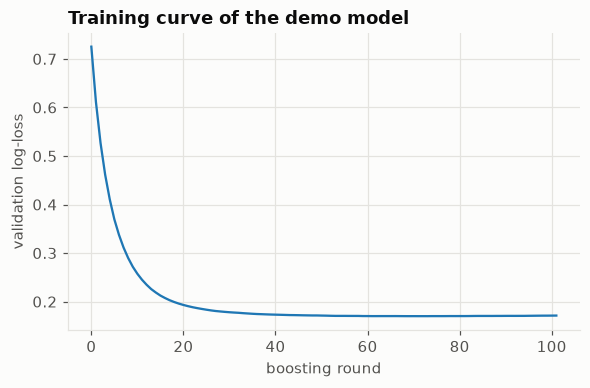

In [12]:
feat = pd.read_parquet(feat_file, columns=F1 + ["sender", "class", "split"])
feat["road_dist"] = msgs["road_dist"].to_numpy()
tr = feat[feat.split == "train"].sample(300_000, random_state=42)
va = feat[feat.split == "val"].sample(100_000, random_state=42)

small = make_model("xgb", 42, n_estimators=300, learning_rate=0.2, max_depth=6)
small.fit(tr[F2], tr["class"], eval_set=[(va[F2], va["class"])], verbose=False)
loss = small.evals_result()["validation_0"]["mlogloss"]
print("stopped after", small.best_iteration + 1, "trees | validation macro-F1 of the small demo model:",
      round(evl.summary_metrics(va["class"], small.predict(va[F2]))["macro_f1"], 3))
plt.figure(figsize=(6, 3.5)); plt.plot(loss); plt.xlabel("boosting round"); plt.ylabel("validation log-loss"); plt.title("Training curve of the demo model"); plt.show()
del tr, va, small

**All experiments.** 20 runs were made with `scripts/02_train_models.py` (about 1.5 hours, GPU). The comparison set is small on purpose:
logistic regression (linear baseline), a decision tree, a random forest and XGBoost, on three feature sets, with two choices of identity for the history features
and with the random split as leakage check. The final model was chosen with the **validation** macro-F1 only; the test set was not used for choosing.

In [13]:
t4 = pd.read_csv(f"{RESULTS_DIR}/paper_tables/T4_all_experiments.csv")
display(t4.round(4))

,experiment,model,features,history_keyed_on,split,class_weighted,val_macro_f1,test_macro_f1,test_balanced_accuracy,test_accuracy,test_mcc,train_seconds
0,xgb_F2_pseudo_rowsplit,xgb,F2,pseudonym,random rows,False,0.9554,0.9544,0.9402,0.9767,0.9632,525.7
1,xgb_F1_pseudo_rowsplit,xgb,F1,pseudonym,random rows,False,0.9544,0.9536,0.9385,0.9762,0.9624,671.0
2,xgb_F2_pseudo_lr05,xgb,F2,pseudonym,by vehicle,False,0.9158,0.9212,0.9017,0.9613,0.9376,193.3
3,xgb_F2_pseudo_d6,xgb,F2,pseudonym,by vehicle,False,0.9154,0.9202,0.9005,0.9609,0.9371,121.2
4,xgb_F2_pseudo_d10,xgb,F2,pseudonym,by vehicle,False,0.9153,0.9200,0.9013,0.9607,0.9366,95.6
5,xgb_F2_pseudo,xgb,F2,pseudonym,by vehicle,False,0.9142,0.9188,0.8997,0.9604,0.9362,224.3
6,rf_F2_pseudo,rf,F2,pseudonym,by vehicle,False,0.9068,0.9124,0.8919,0.9582,0.9325,300.8
7,xgb_F1_pseudo,xgb,F1,pseudonym,by vehicle,False,0.9034,0.9081,0.8848,0.9558,0.9287,84.0
8,xgb_F2_pseudo_weighted,xgb,F2,pseudonym,by vehicle,True,0.9065,0.9081,0.9037,0.9518,0.9227,404.3
9,tree_F2_pseudo,tree,F2,pseudonym,by vehicle,False,0.9017,0.9065,0.8889,0.9549,0.9273,818.6


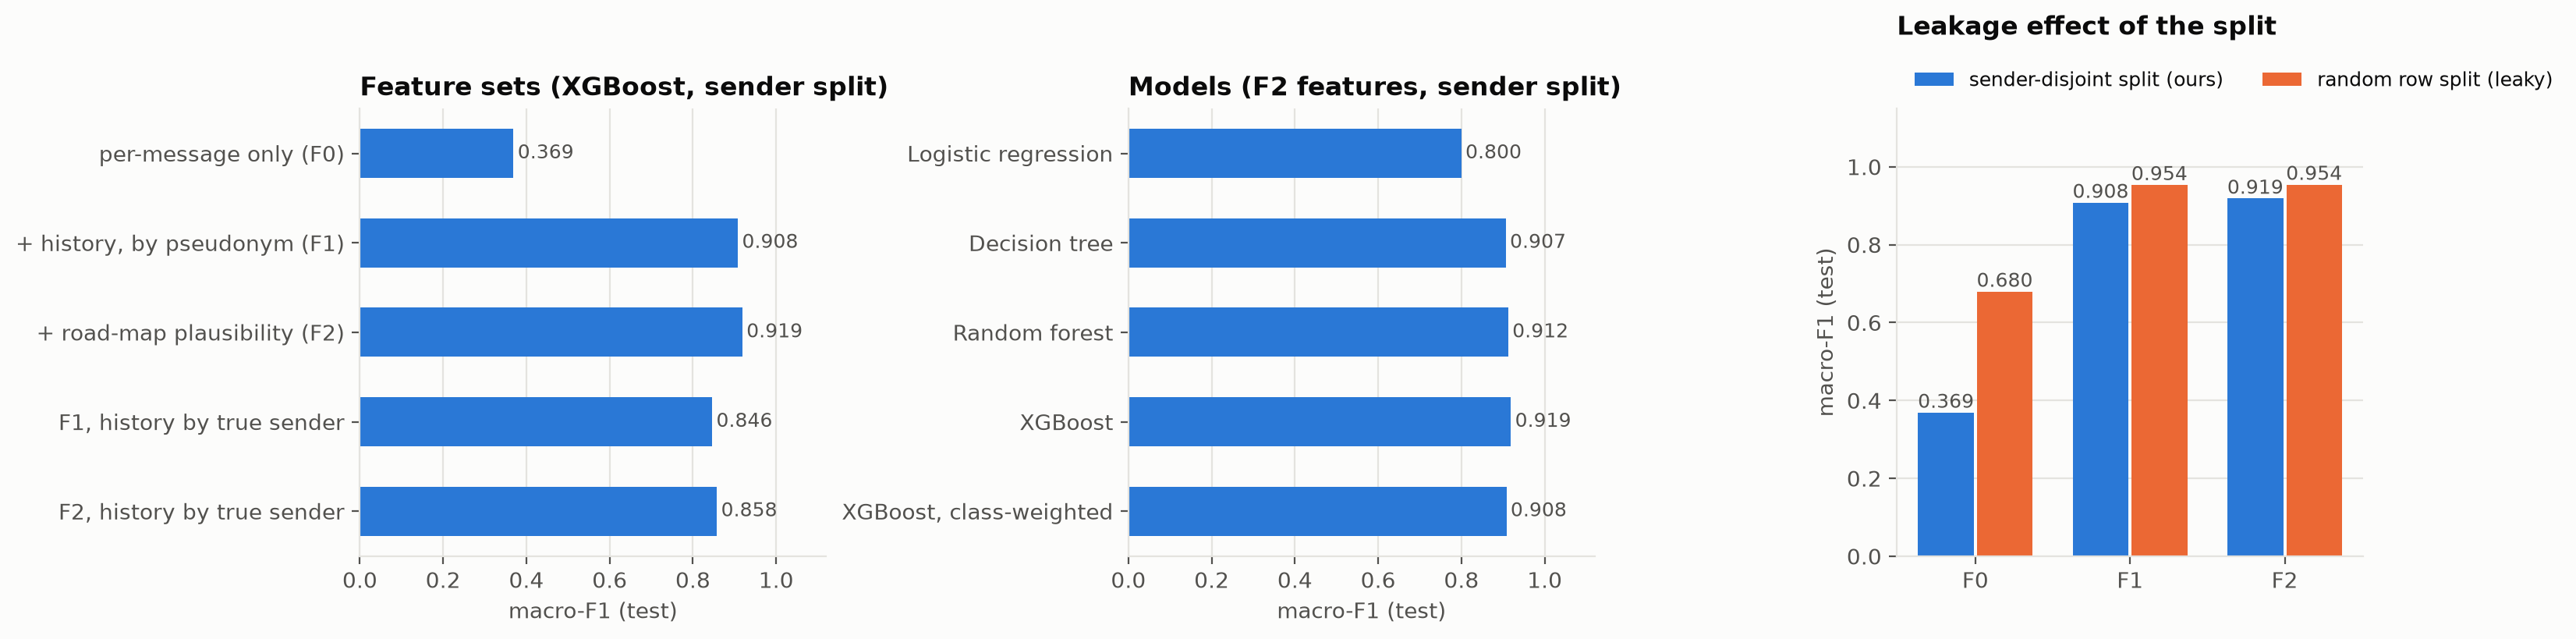

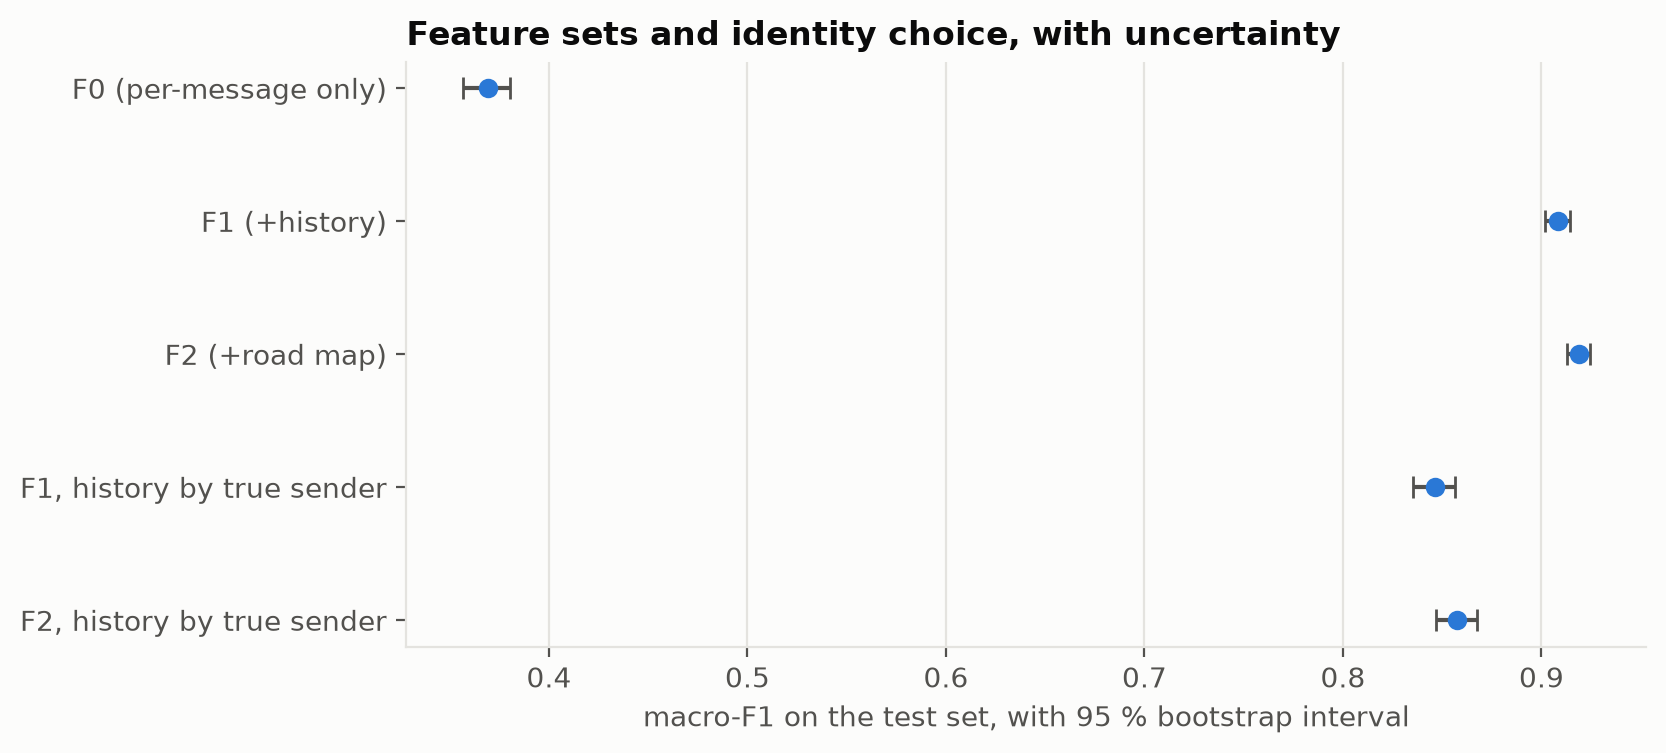

,comparison,mean_macro_f1_difference,ci_low,ci_high,share_of_resamples_positive
0,F1 (+history) minus F0 (per-message only),0.5394,0.5275,0.5519,1.0
1,F2 (+road map) minus F1 (+history),0.0107,0.0085,0.0131,1.0
2,"F2 (+road map) minus F2, history by true sender",0.0613,0.0516,0.0712,1.0
3,"F1 (+history) minus F1, history by true sender",0.0621,0.0528,0.0718,1.0


In [14]:
show_fig("experiment_comparison.png")
show_fig("bootstrap_ablation_ci.png", width=700)
display(pd.read_csv(f"{RESULTS_DIR}/paper_tables/T5b_paired_comparisons.csv").round(4))

What the experiments show:

- **Features matter far more than the model.** The per-message features F0 give macro-F1 0.37; the history features F1 give 0.91; the road map F2 adds 0.011
  (paired bootstrap interval above 0). Random forest, decision tree and XGBoost end within 0.015 of each other on F2; logistic regression is clearly worse (0.80).
- **The history should be keyed on the pseudonym, not on the true vehicle id.** The true id is not visible to a receiver, and it is also worse (0.858 against 0.919),
  because it hides the pseudonym changes that are the signature of the Sybil attacks.
- **Class weights** did not help macro-F1; **hyper-parameters** hardly matter (validation macro-F1 0.9142 to 0.9158 for four settings), so the model is limited by the data, not by tuning.
- **The random split inflates the score** (F0: 0.369 to 0.680; F2: 0.919 to 0.954).

### Step 5 - The final model

`xgb_F2_pseudo_d6`: XGBoost, depth 6, learning rate 0.10, early stopping on the validation set, 179 trees kept. The model card is saved with the model.
Here we predict the whole test set (478 186 messages of 3 710 vehicles that the model has never seen) and compute the metrics again.

In [15]:
test = feat[feat.split == "test"].copy()
del feat
pipe = Pipeline.load()
card = pipe.card
proba = pipe.predict_proba(test)
pred, y = proba.argmax(1), test["class"].to_numpy()

live = evl.summary_metrics(y, pred)
print({k: round(v, 4) for k, v in live.items()})
print("same as in the model card:", all(abs(live[k] - card["test"][k]) < 1e-3 for k in ("macro_f1", "balanced_accuracy", "accuracy", "mcc")))
per_class = evl.per_class_table(y, pred, NAMES)
display(per_class.round(3))

{'accuracy': 0.9609, 'balanced_accuracy': 0.9005, 'macro_f1': 0.9202, 'weighted_f1': 0.9594, 'mcc': 0.9371, 'binary_f1_misbehaving': 0.9767}
same as in the model card: True


,class,name,precision,recall,f1,support
0,0,Genuine,0.971,1.000,0.985,288005
1,1,Constant position,0.990,0.994,0.992,6246
2,2,Constant position offset,0.994,0.870,0.928,6566
3,3,Random position,0.989,0.990,0.990,5527
4,4,Random position offset,0.991,0.995,0.993,6924
5,5,Constant speed,0.995,0.994,0.994,6103
6,6,Constant speed offset,0.997,0.999,0.998,6924
7,7,Random speed,0.994,0.995,0.995,6752
8,8,Random speed offset,0.998,0.996,0.997,6887
9,9,Eventual stop,1.000,0.815,0.898,5995


**How certain are these numbers?** The messages of one vehicle are not independent, so the bootstrap resamples whole **vehicles** (within each class), 1 000 times
(`scripts/07_uncertainty_and_errors.py`). We also repeat the whole training on three other random vehicle splits (`scripts/08_seed_robustness.py`).

,metric,estimate,ci_low,ci_high
0,accuracy,0.9609,0.9576,0.9644
1,balanced accuracy,0.9005,0.8942,0.9072
2,macro-F1,0.9202,0.9146,0.9258
3,MCC,0.9371,0.9318,0.9425
4,vehicle-level macro-F1 (majority vote),0.9567,0.9464,0.9669


,split_seed,test_vehicles,macro_f1,balanced_accuracy,accuracy,mcc
0,42,3710.0,0.9202,0.9005,0.9609,0.9371
1,1,3710.0,0.9203,0.9006,0.9591,0.9358
2,2,3710.0,0.9189,0.8994,0.9585,0.9352
3,3,3710.0,0.9194,0.8987,0.9602,0.9366
4,mean,NaN,0.9197,0.8998,0.9597,0.9362
5,std,NaN,0.0007,0.0009,0.0011,0.0008


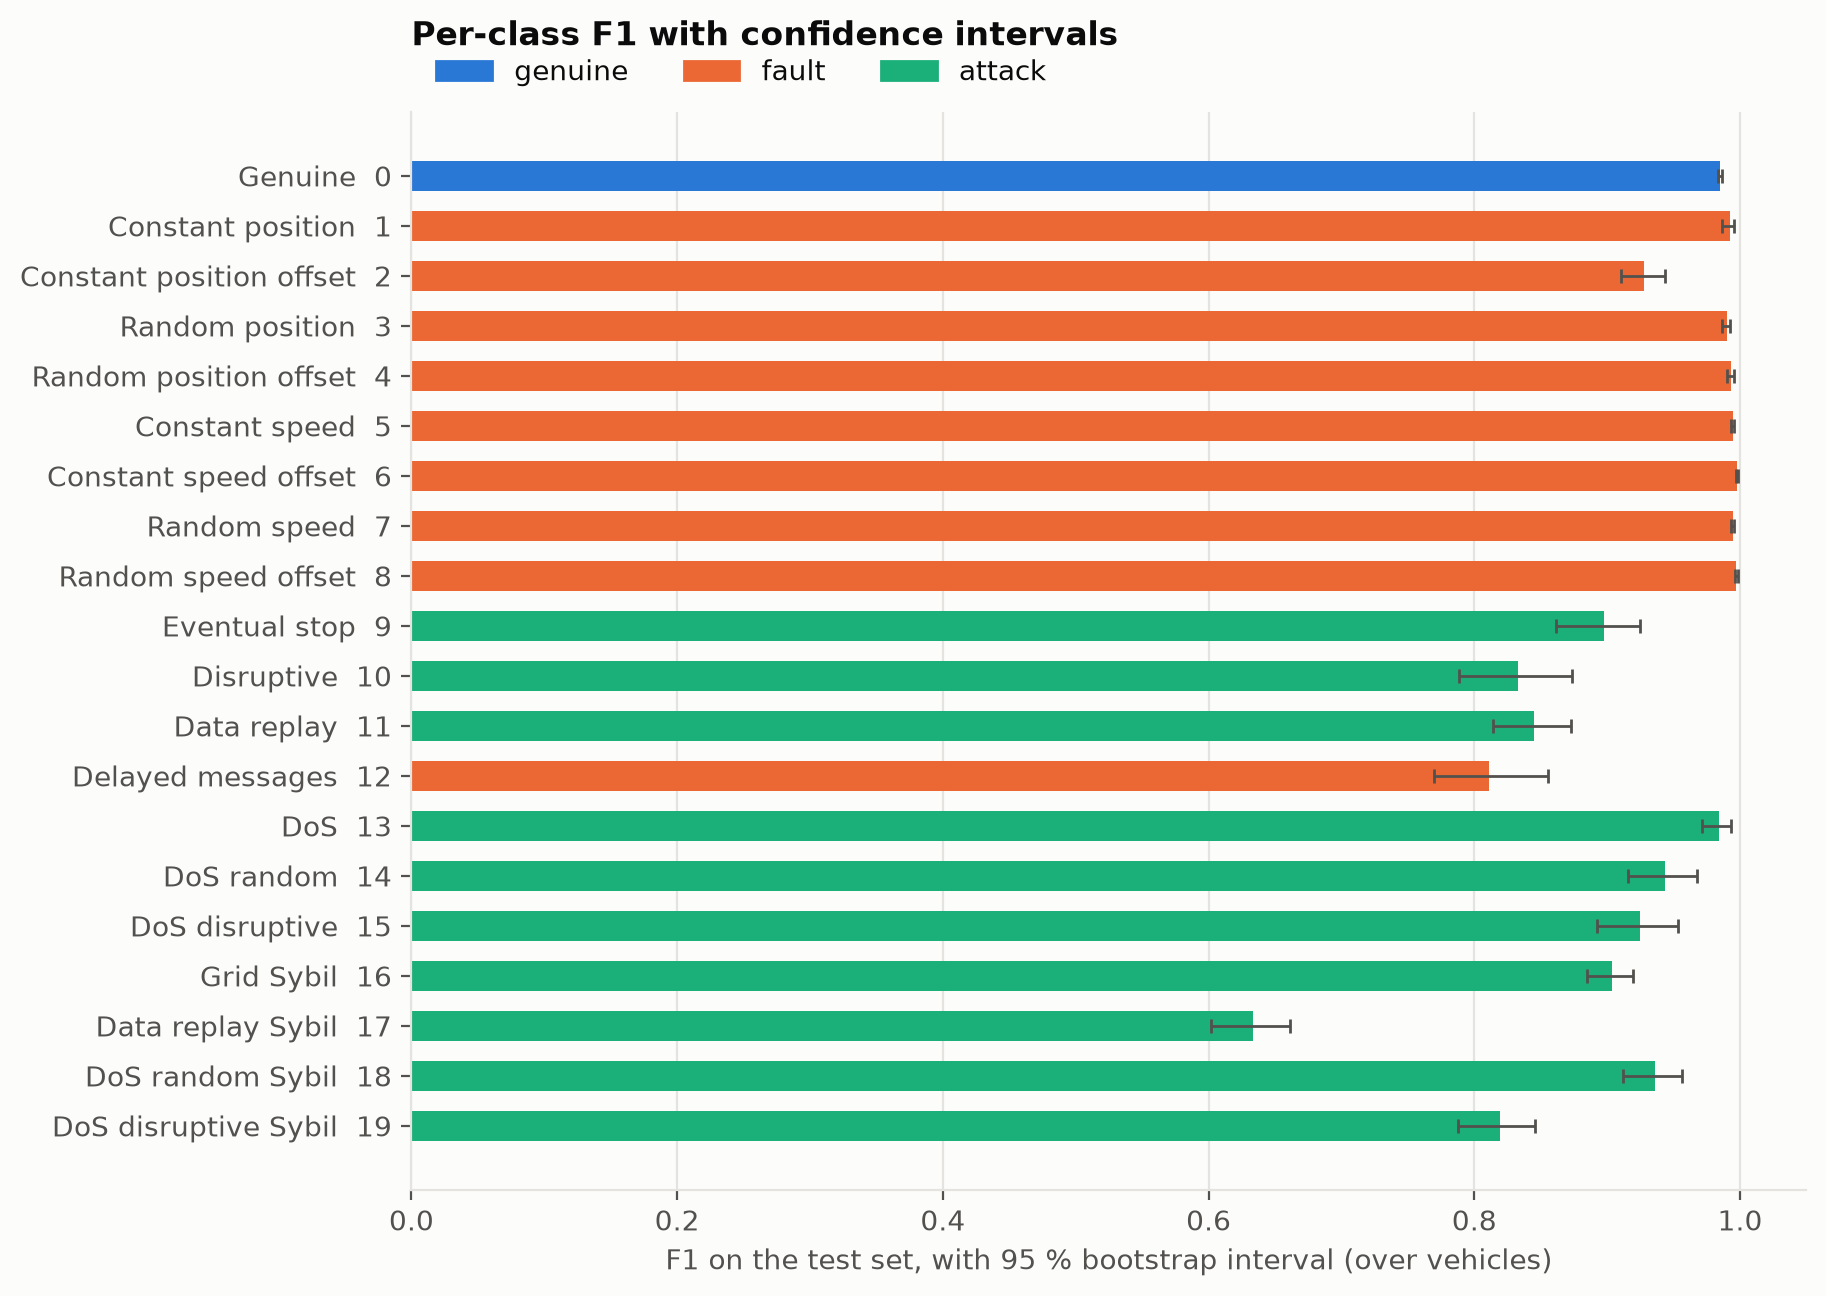

In [16]:
display(pd.read_csv(f"{RESULTS_DIR}/paper_tables/T7a_final_model_with_ci.csv").round(4))
display(pd.read_csv(f"{RESULTS_DIR}/paper_tables/T7b_split_seed_robustness.csv").round(4))
show_fig("final_per_class_f1_ci.png", width=750)

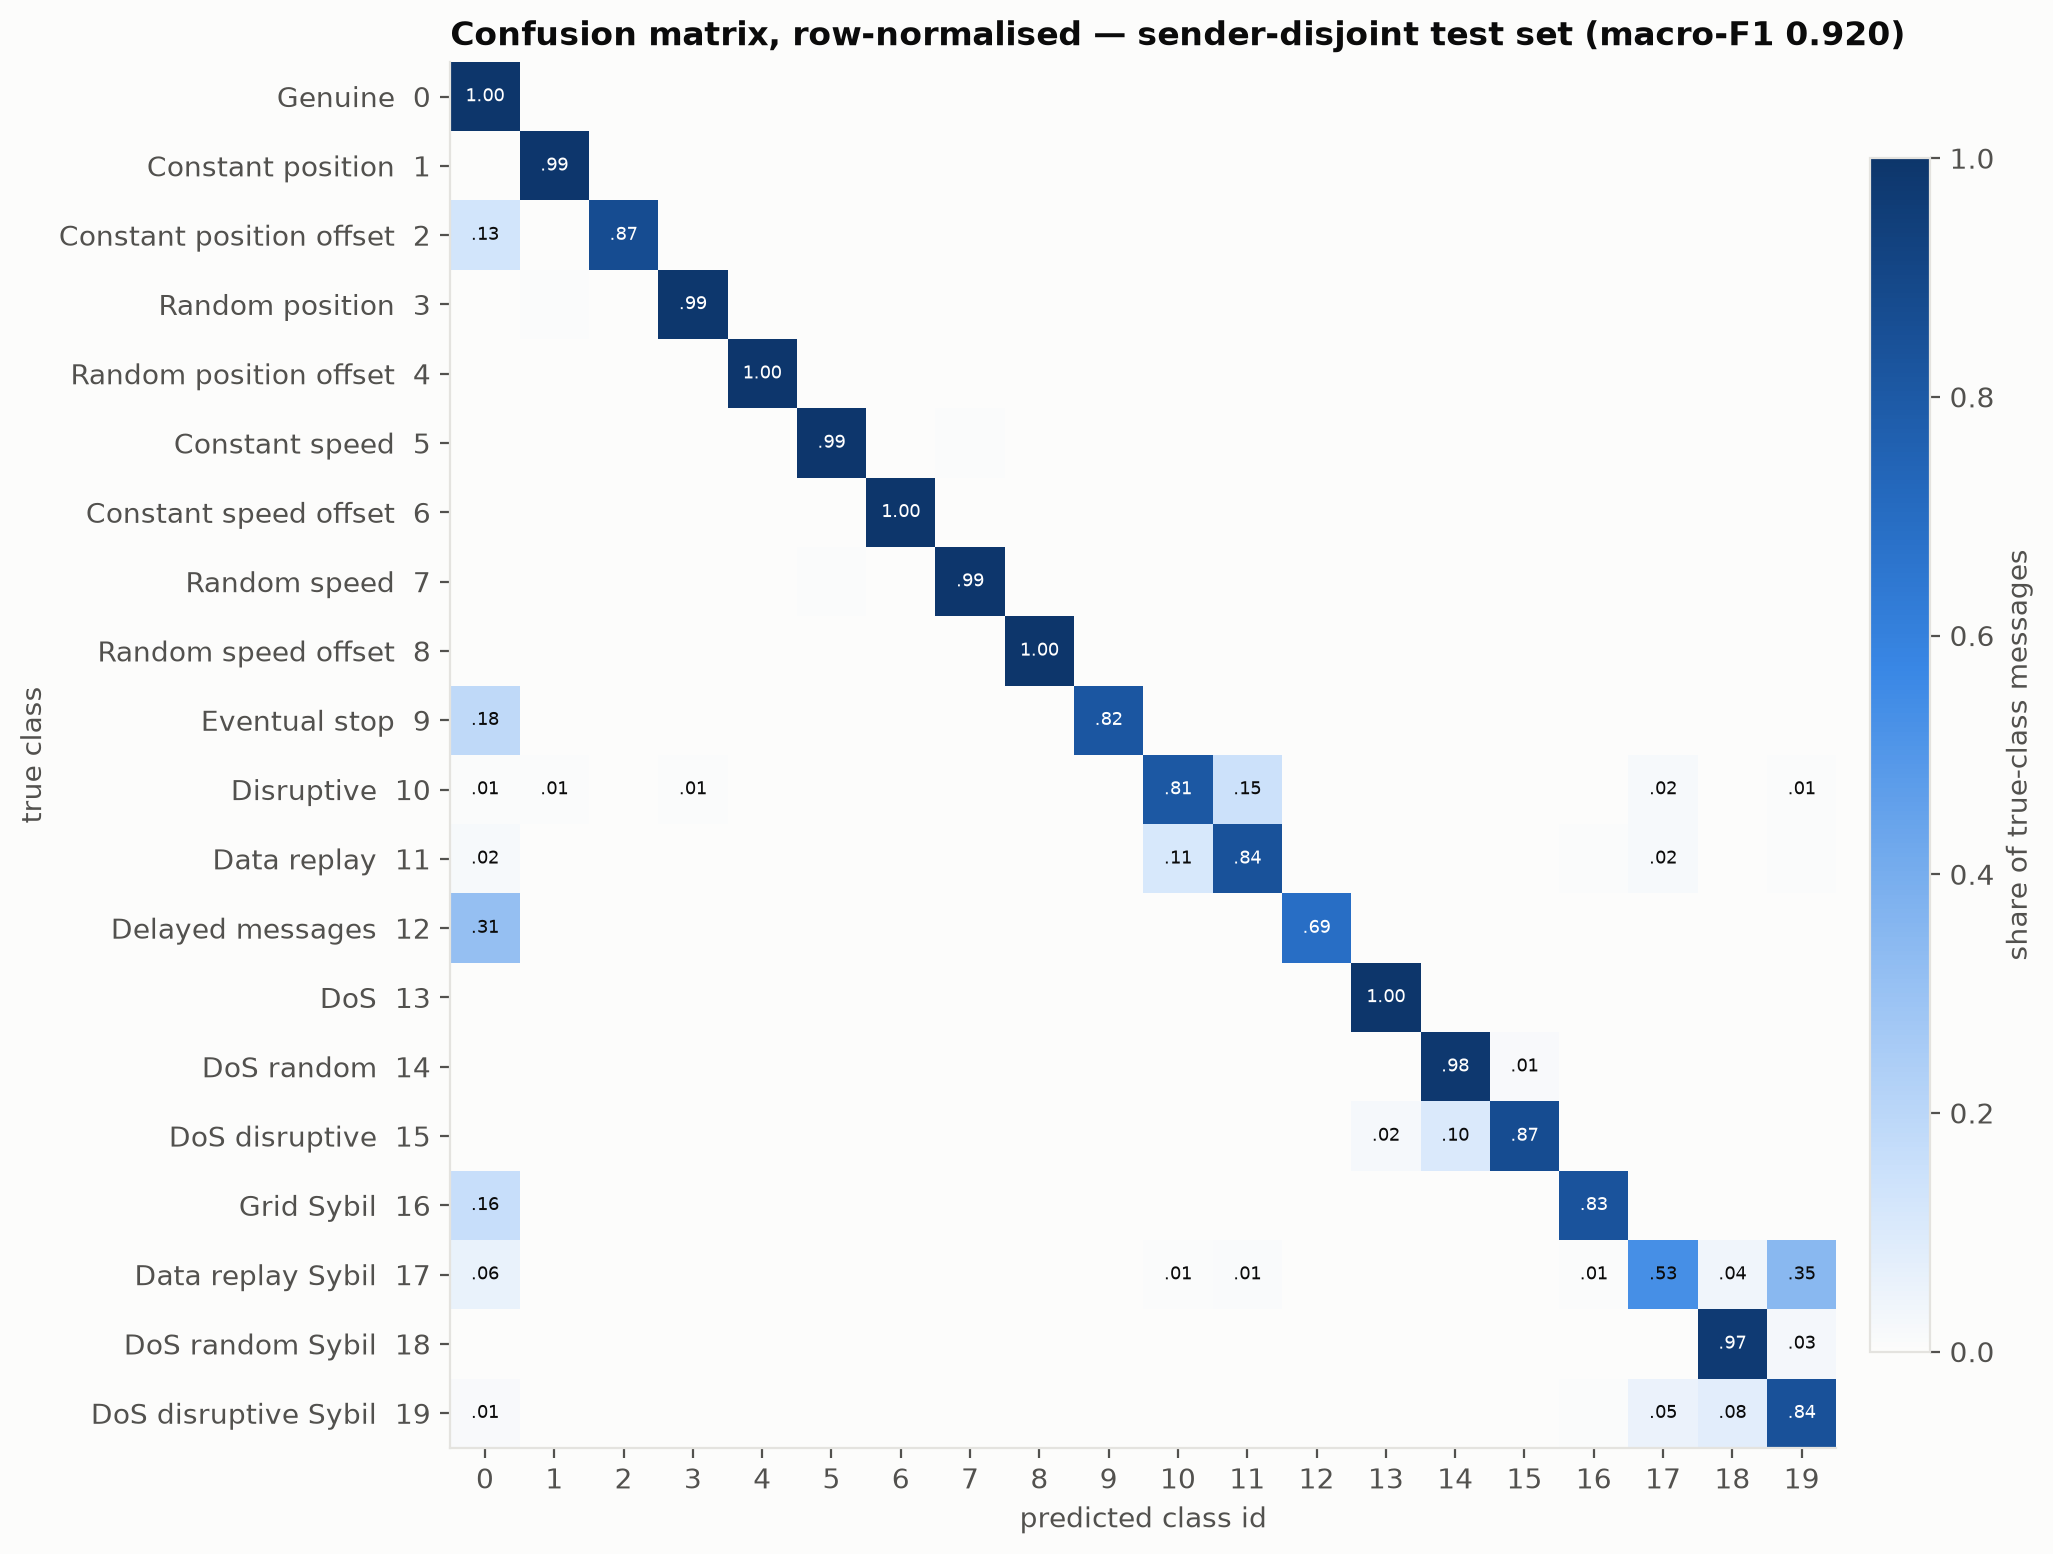

,true_class,true_name,predicted_class,predicted_name,messages,share_of_true_class,share_of_all_errors
0,16,Grid Sybil,0,Genuine,3961,0.1624,0.2121
1,17,Data replay Sybil,19,DoS disruptive Sybil,2268,0.3464,0.1214
2,15,DoS disruptive,14,DoS random,2008,0.1038,0.1075
3,12,Delayed messages,0,Genuine,1881,0.3116,0.1007
4,9,Eventual stop,0,Genuine,1109,0.1850,0.0594
5,19,DoS disruptive Sybil,18,DoS random Sybil,1051,0.0808,0.0563
6,2,Constant position offset,0,Genuine,842,0.1282,0.0451
7,10,Disruptive,11,Data replay,809,0.1464,0.0433
8,19,DoS disruptive Sybil,17,Data replay Sybil,688,0.0529,0.0368
9,11,Data replay,10,Disruptive,669,0.1097,0.0358


In [17]:
show_fig("final_confusion_matrix.png", width=900)
display(pd.read_csv(f"{RESULTS_DIR}/paper_tables/T9a_top_confusions.csv"))

**Where and why does the model fail?** The main errors are explained below. Each explanation was **tested on the test data**
(`error_cause_checks.json`), not assumed.

In [18]:
checks = json.load(open(f"{RESULTS_DIR}/error_cause_checks.json"))
for name, c in checks.items():
    print(name.upper().replace("_", " "))
    for k, v in c.items():
        print(f"   {k}: {v}")

EVENTUAL STOP
   claim: errors are the messages sent BEFORE the vehicle stops
   messages: 5995
   errors: 1109
   share_of_errors_predicted_genuine: 1.0
   share_of_errors_with_speed_above_0.5: 0.9378
   error_rate_when_vehicle_is_moving: 1.0
   error_rate_when_vehicle_is_stopped: 0.0139
GRID SYBIL
   claim: one identity per attacker (its own, genuine-looking beacons) causes the errors
   messages: 24390
   errors: 4150
   pseudonyms_per_vehicle_median: 3.0
   share_of_errors_in_the_single_worst_pseudonym_of_each_vehicle: 0.9629
   error_rate_inside_that_pseudonym: 0.6682
   share_of_rows_with_placeholder_pseudonym_1: 0.2084
   error_rate_placeholder_pseudonym_1: 0.0004
   error_rate_other_pseudonyms: 0.2148
   worst_pseudonym_median_distance_to_road_map_m: 1.9587
   other_pseudonyms_median_distance_to_road_map_m: 1.9886
   worst_pseudonym_share_of_rows_off_map(>5m): 0.0
   other_pseudonyms_share_of_rows_off_map(>5m): 0.0
   worst_pseudonym_median_speed_position_disagreement: 0.3709
 

Reading the checks:

- **Eventual stop (9):** every error is predicted as Genuine, and all messages sent while the vehicle is still moving are missed (error rate 1.00 while moving, 0.01 once stopped).
  The label is per vehicle, so the driving before the stop carries the attack label, but it looks genuine.
- **Grid Sybil (16):** 96 % of the errors sit in one single pseudonym of each vehicle; the other pseudonyms (the ghost vehicles) are found. The next cell of the check shows how that pseudonym differs.
- **Delayed messages (12):** the zero-filled start is always found (error rate 0.0); the delayed genuine-looking messages are hard (error rate 0.71).
- **Constant position offset (2):** an offset that puts the message off the road map is found (error rate 0.002); errors are offsets that still land on a road (0.65).
- **First message of a pseudonym:** it has no history. These 3.7 % of the messages cause 26 % of all errors, and they are half of all messages of Data replay Sybil (17).
  This class is confused with DoS disruptive Sybil (19): 35 % of class 17 is predicted as 19.

**Calibration and confidence.** The reports say "high", "moderate" or "low" confidence. This is only useful if the words mean something,
so we checked how often the model is right inside each level:

,confidence_level,messages,share_of_messages,accuracy,share_of_all_errors
0,high,444211,0.9290,0.9782,0.5195
1,moderate,26194,0.0548,0.7893,0.2954
2,low,7781,0.0163,0.5557,0.1851


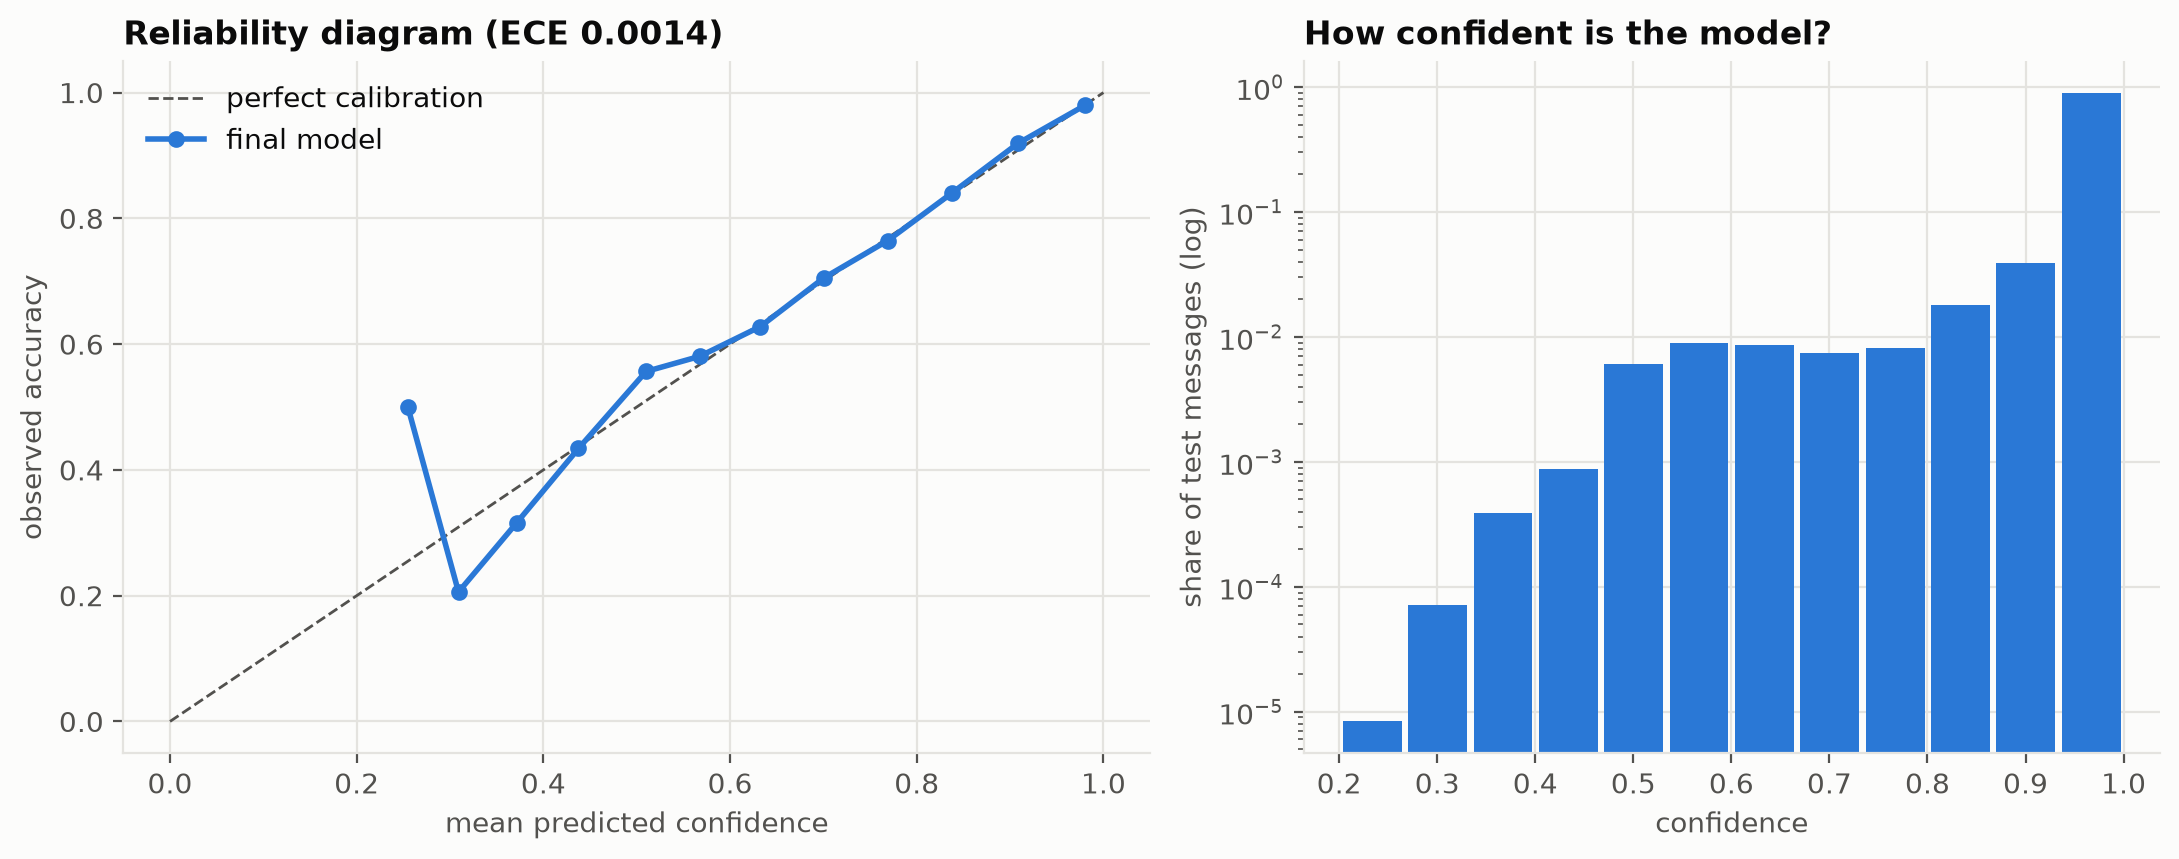

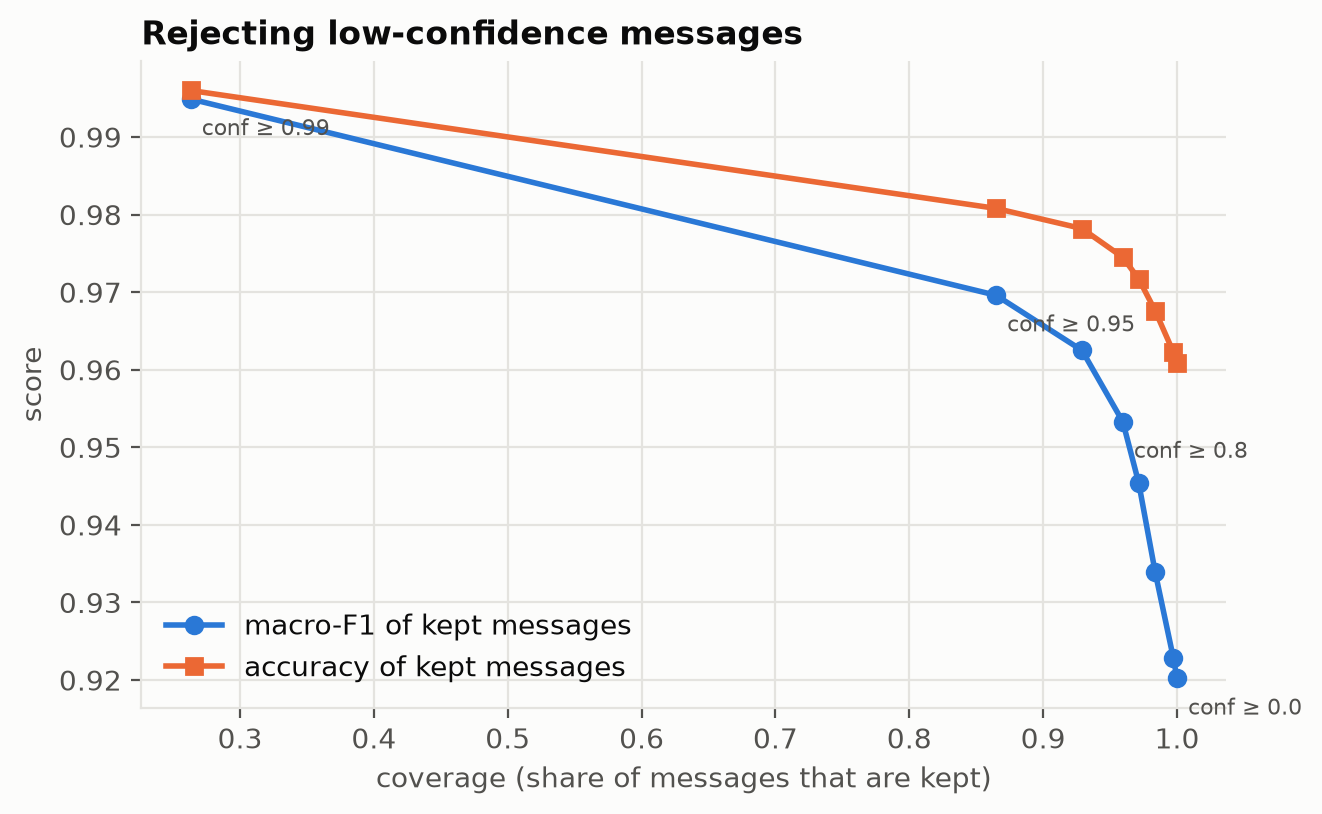

In [19]:
display(pd.read_csv(f"{RESULTS_DIR}/paper_tables/T9b_confidence_levels.csv"))
show_fig("calibration_reliability.png", width=850)
show_fig("selective_prediction.png", width=520)

"High" confidence (93 % of the messages) is right 97.8 % of the time, "moderate" 78.9 %, "low" 55.6 %; a message with low confidence is 5 times more likely to be wrong than the average.
The expected calibration error is 0.0014. If the messages with a confidence below 0.95 are held back, the macro-F1 of the remaining 86 % rises from 0.920 to 0.970.

**Published numbers for comparison** (reported by their authors; different splits and features, so they cannot be compared directly):

In [20]:
display(pd.read_csv(f"{RESULTS_DIR}/paper_tables/T11_literature_context.csv"))

,source,task,split,features,reported
0,This work,"20 classes, per message",by vehicle,per-message only (F0),macro-F1 0.369
1,This work,"20 classes, per message",random rows,per-message only (F0),macro-F1 0.680
2,This work,"20 classes, per message",by vehicle,"F2: history + road map, no identifiers",macro-F1 0.920
3,Slama et al. 2022 (same CSV),"20 classes, per message",not stated (70/30),"raw kinematics + noise, identifiers dropped",F1 0.696 (random forest)
4,Youness et al. 2025 (VeMisNet),"20 classes, sequences of 10",random sequences 80/20,14 kinematic + communication features,"accuracy 0.918, F1 0.909, balanced accuracy 0.739"
5,Khan et al. 2025,"20 classes, per message",random rows 49/30/21,identifiers and noise fields among inputs,accuracy 96.15 %
6,Kamel et al. 2020 (dataset paper),"binary, per message",not applicable (rule-based),plausibility checks,F1 0.899 on MixAll


### Step 6 - Explaining the predictions with SHAP

SHAP gives, for one message and one class, how much each feature moved the model's score for that class. We use the exact algorithm for tree models (`TreeExplainer`).
For every message the values add up: `base value + sum of SHAP values = model output`. The scale is the model's raw score (log-odds), not probability.

largest deviation from additivity: 7.62939453125e-06


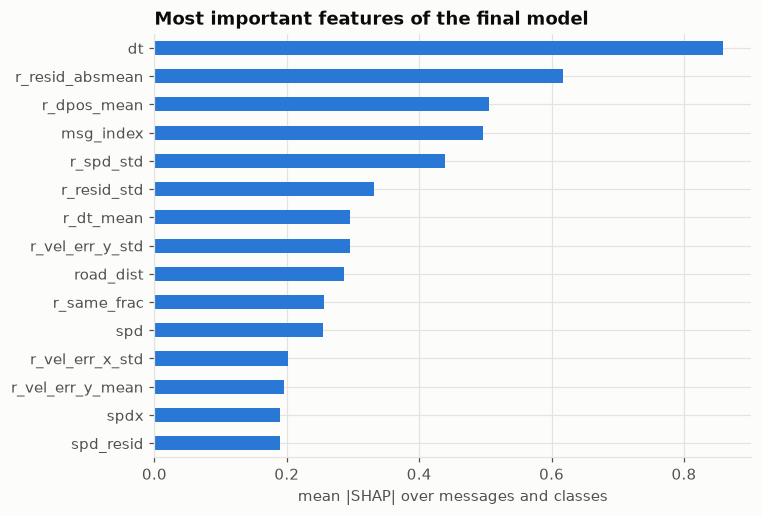

In [21]:
samp = test.groupby("class", group_keys=False).sample(n=50, random_state=42)             # 1 000 test messages, 50 per class
sv = pipe.explainer.shap_values(samp)                                                   # (messages, features, classes)
margins = pipe.explainer.margins(samp)
print("largest deviation from additivity:", float(np.abs(sv.sum(1) + pipe.explainer.base_values - margins).max()))

global_importance = pd.Series(np.abs(sv).mean(axis=(0, 2)), index=F2).sort_values(ascending=False).head(15)
plt.figure(figsize=(7, 5)); global_importance[::-1].plot.barh(color="#2a78d6"); plt.xlabel("mean |SHAP| over messages and classes")
plt.title("Most important features of the final model"); plt.show()

The most important features are the time between messages `dt`, the speed-vs-position disagreement, the mean position jump, the message counter and the spread of speed.
None of them is an identifier or an absolute time. The next figure shows which features drive which class (each class column scaled to its maximum):

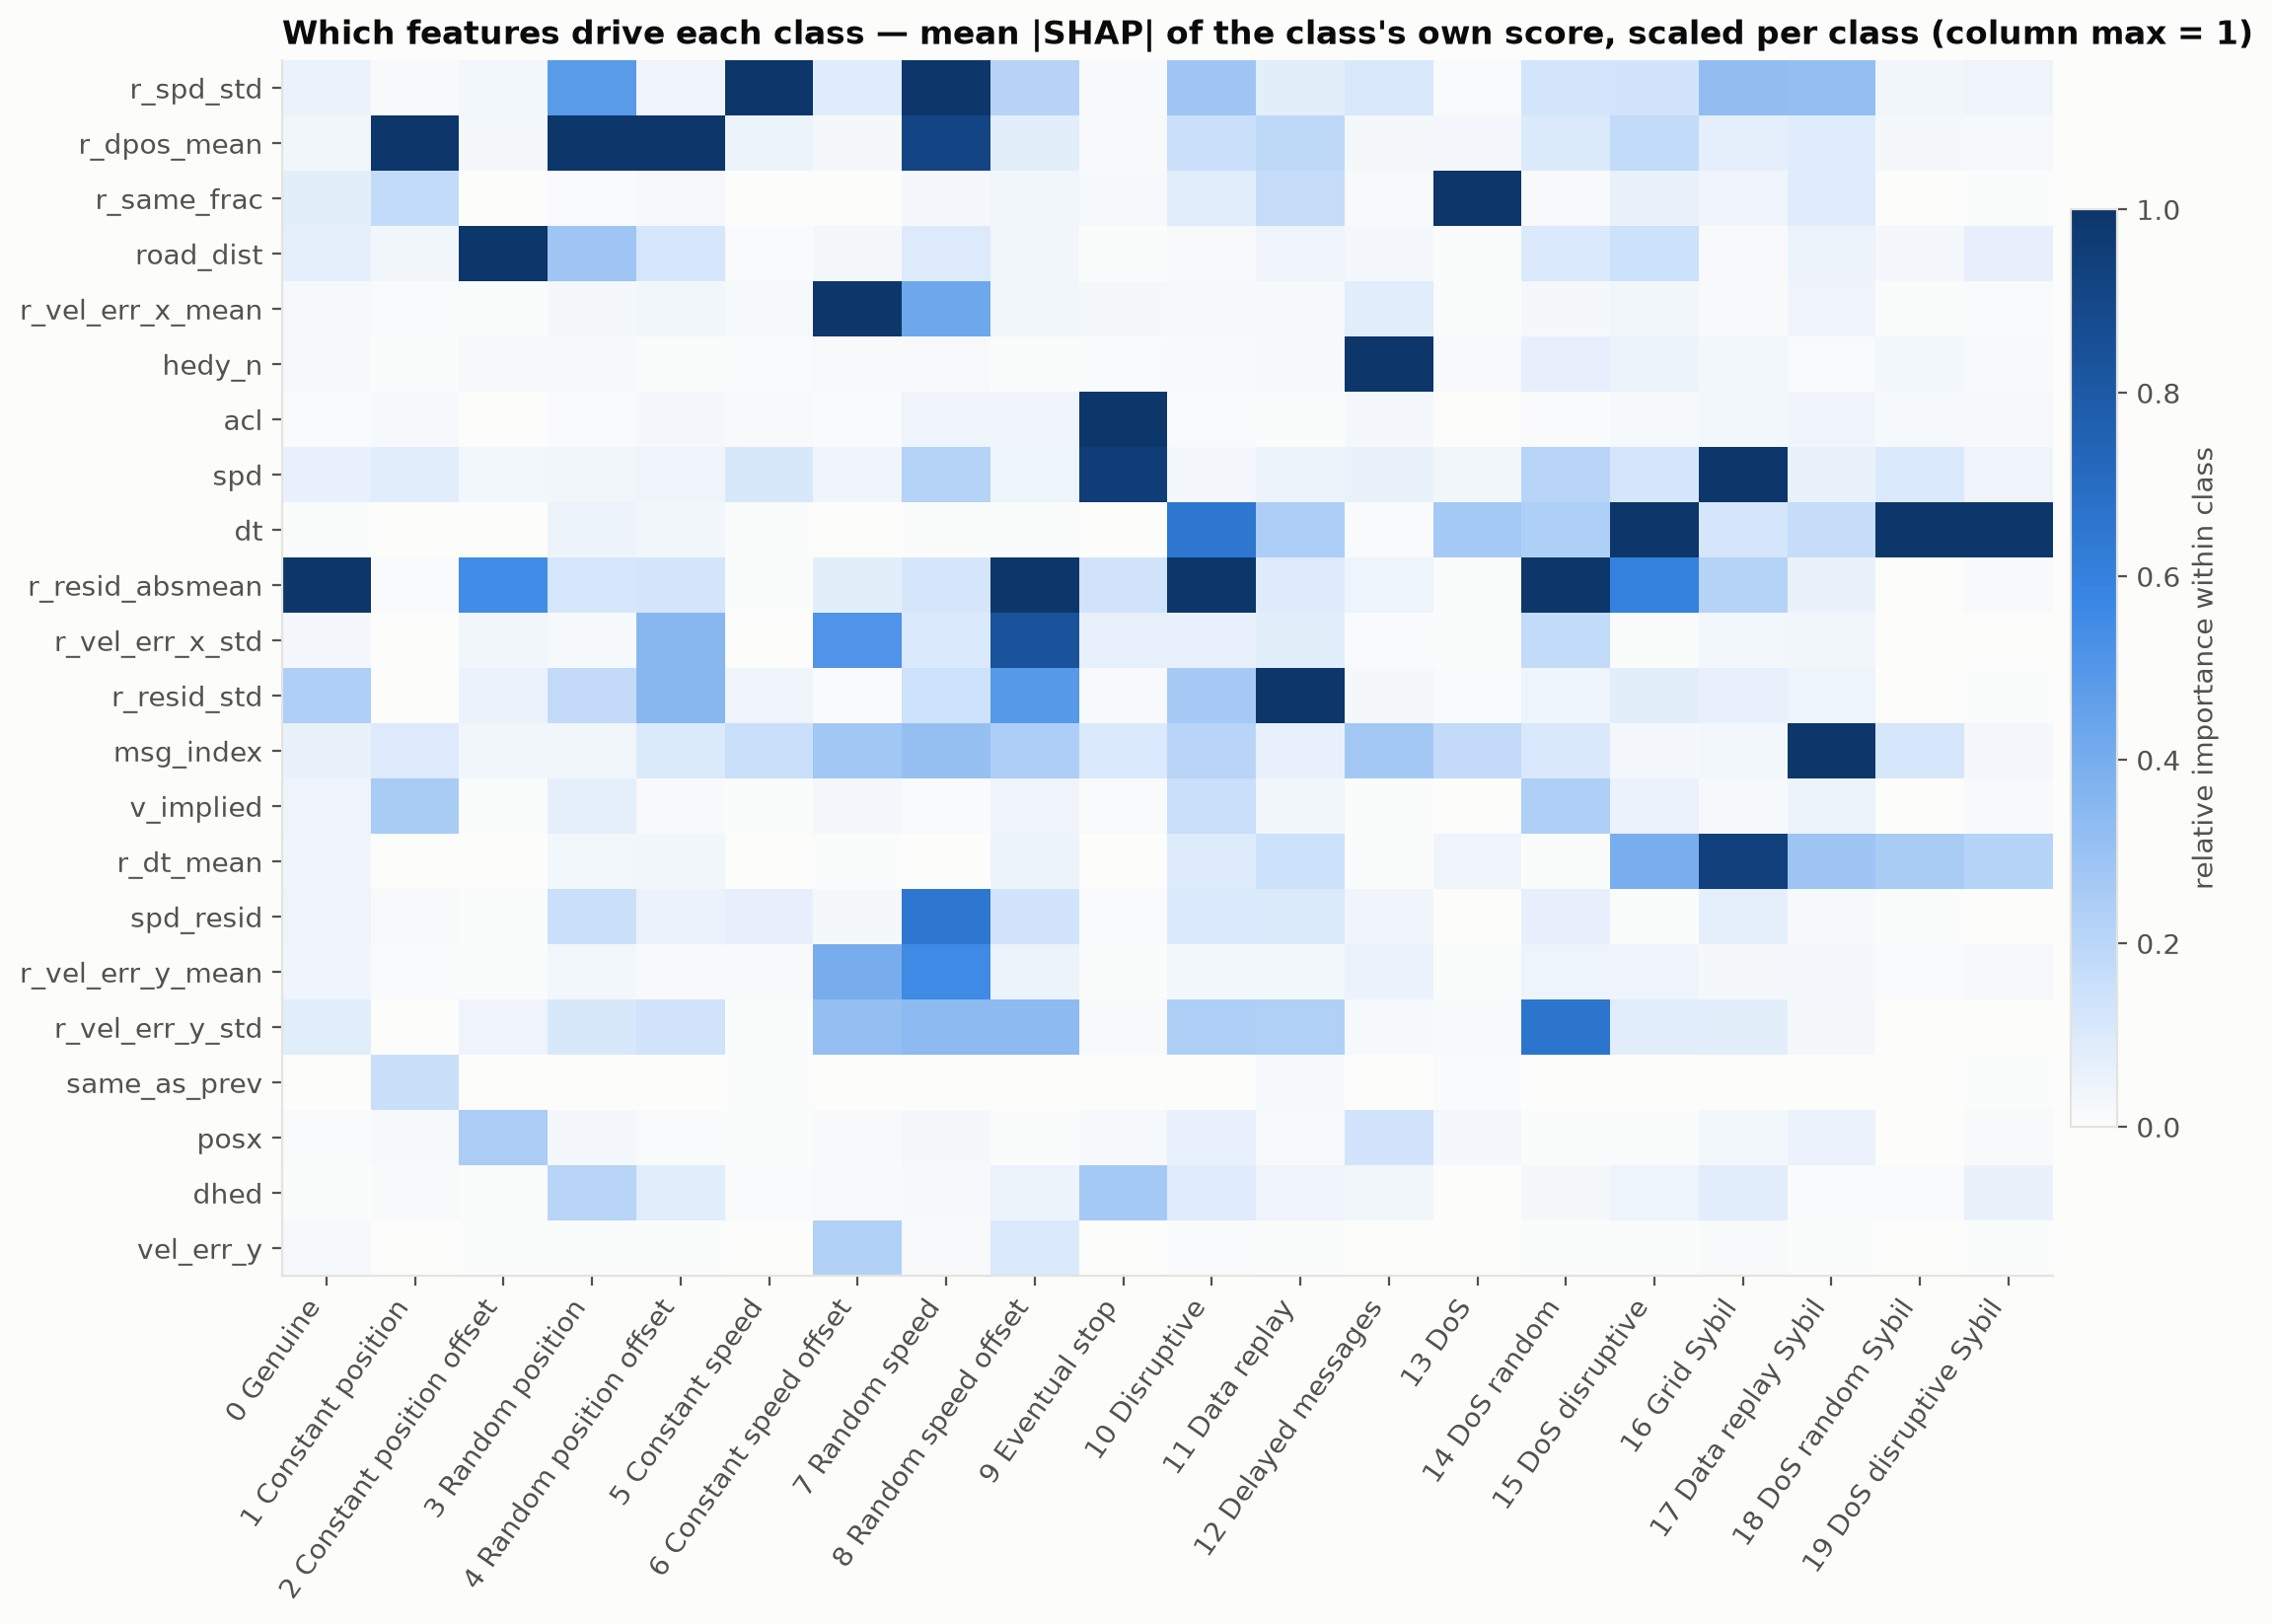

In [22]:
show_fig("shap_per_class_heatmap.png", width=950)

Every class is driven by the feature that its definition suggests: Constant speed by the spread of speed `r_spd_std`, Constant speed offset by the mean velocity error,
Constant position offset by `road_dist`, the DoS family by `dt` and the share of repeated messages, Data replay Sybil by the message counter (a fresh pseudonym).

**One message.** A DoS message that the model recognised. Blue bars push towards the predicted class, orange bars push away.

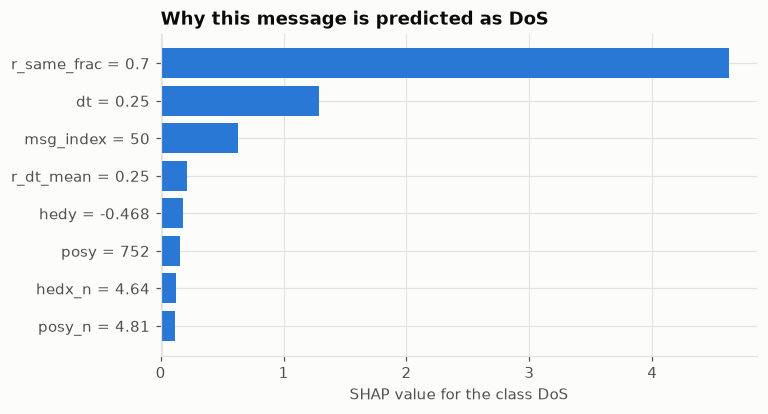

In [23]:
pred_s = pipe.predict_proba(samp).argmax(1)
i = int(np.where((samp["class"].to_numpy() == 13) & (pred_s == 13))[0][0])
row_sv = sv[i, :, 13]
top = np.argsort(np.abs(row_sv))[::-1][:8][::-1]
plt.figure(figsize=(7, 3.8))
plt.barh([f"{F2[j]} = {samp.iloc[i][F2[j]]:.3g}" for j in top], row_sv[top], color=["#2a78d6" if row_sv[j] > 0 else "#eb6834" for j in top])
plt.axvline(0, color="#52514e", lw=0.8); plt.xlabel("SHAP value for the class DoS"); plt.title("Why this message is predicted as DoS"); plt.show()

**Are the explanations faithful to the model?** Two checks (made by `scripts/03_finalize_and_explain.py` on 3 000 test messages):
additivity (above, and below), and a perturbation test: we replace the three features that SHAP calls most important by the values of a genuine message.
If SHAP is right, the prediction must change much more than when we replace three random features.

,mean_prob_drop,share_prediction_flipped
top3_shap,0.742,0.789
random3,0.081,0.091


additivity error on 3000 messages: 1.1682510375976562e-05


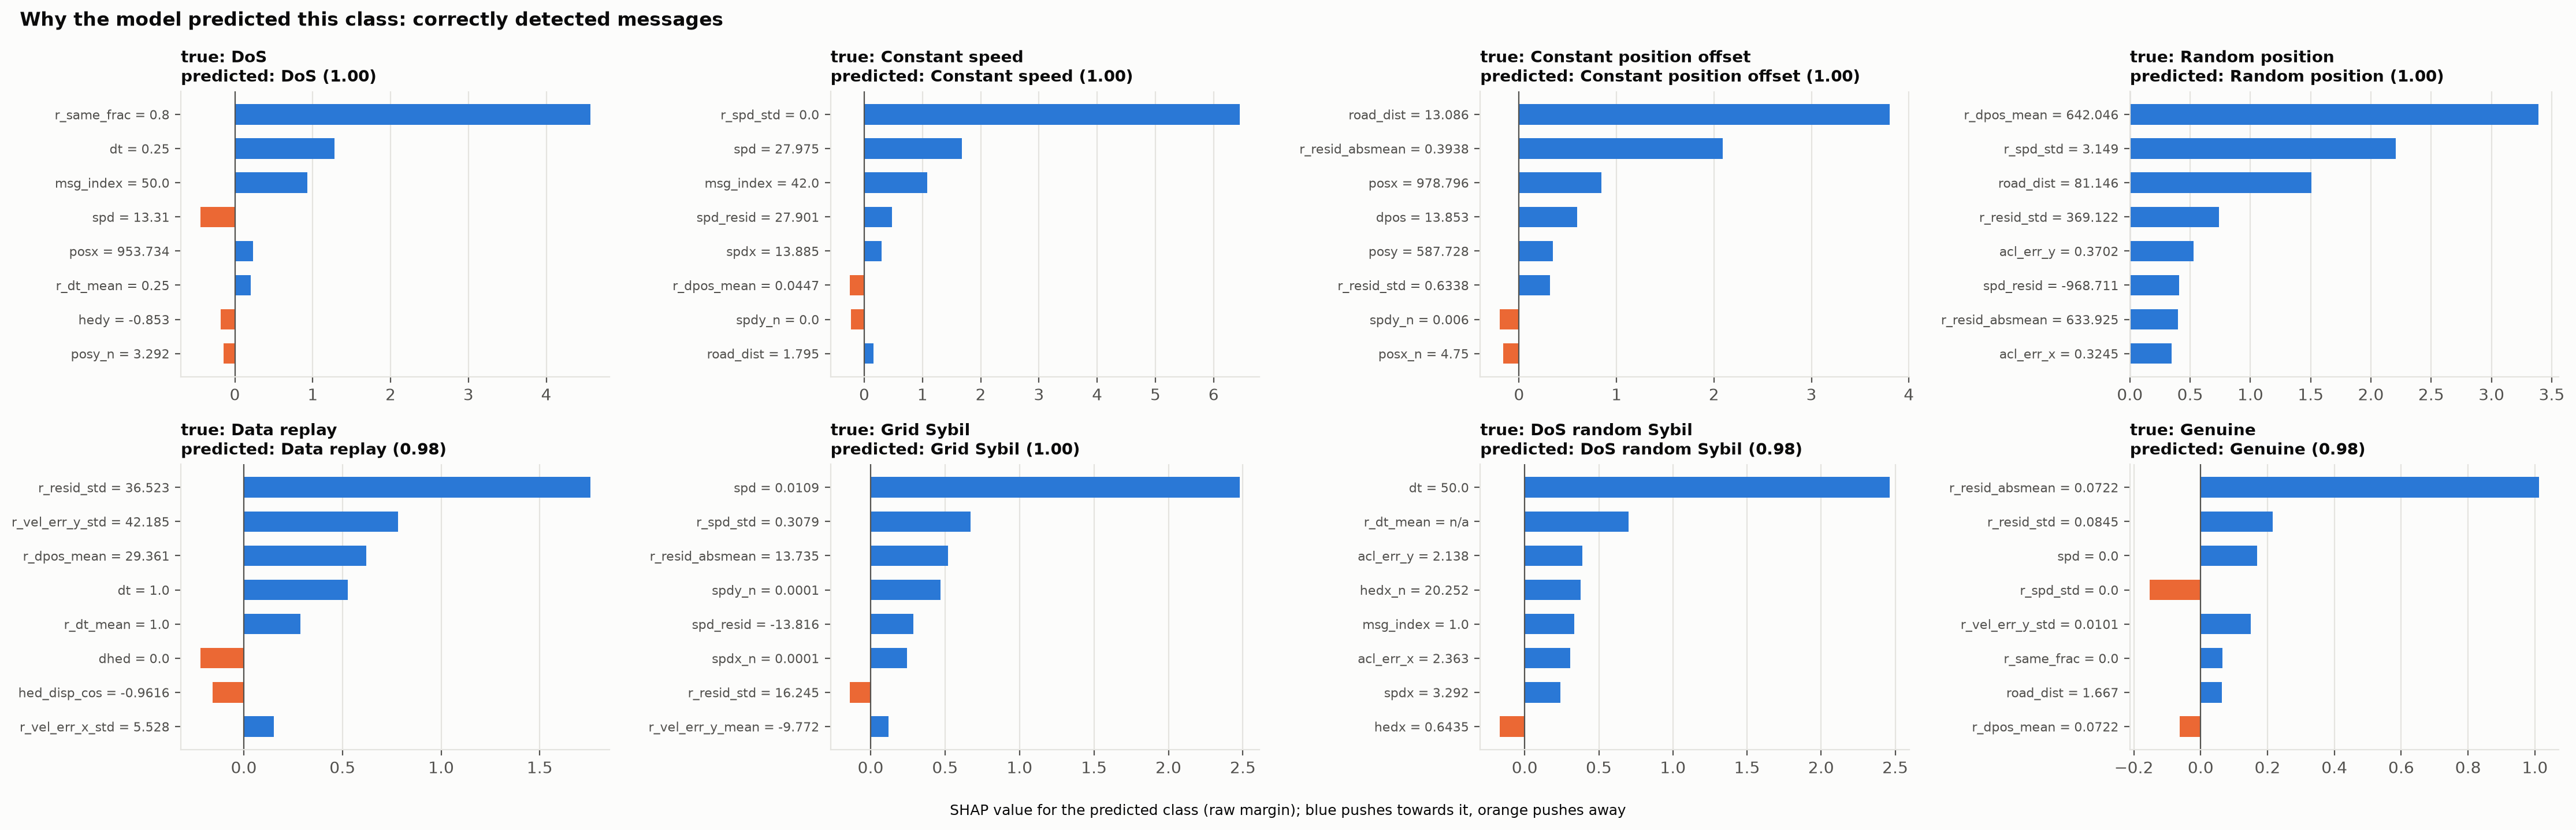

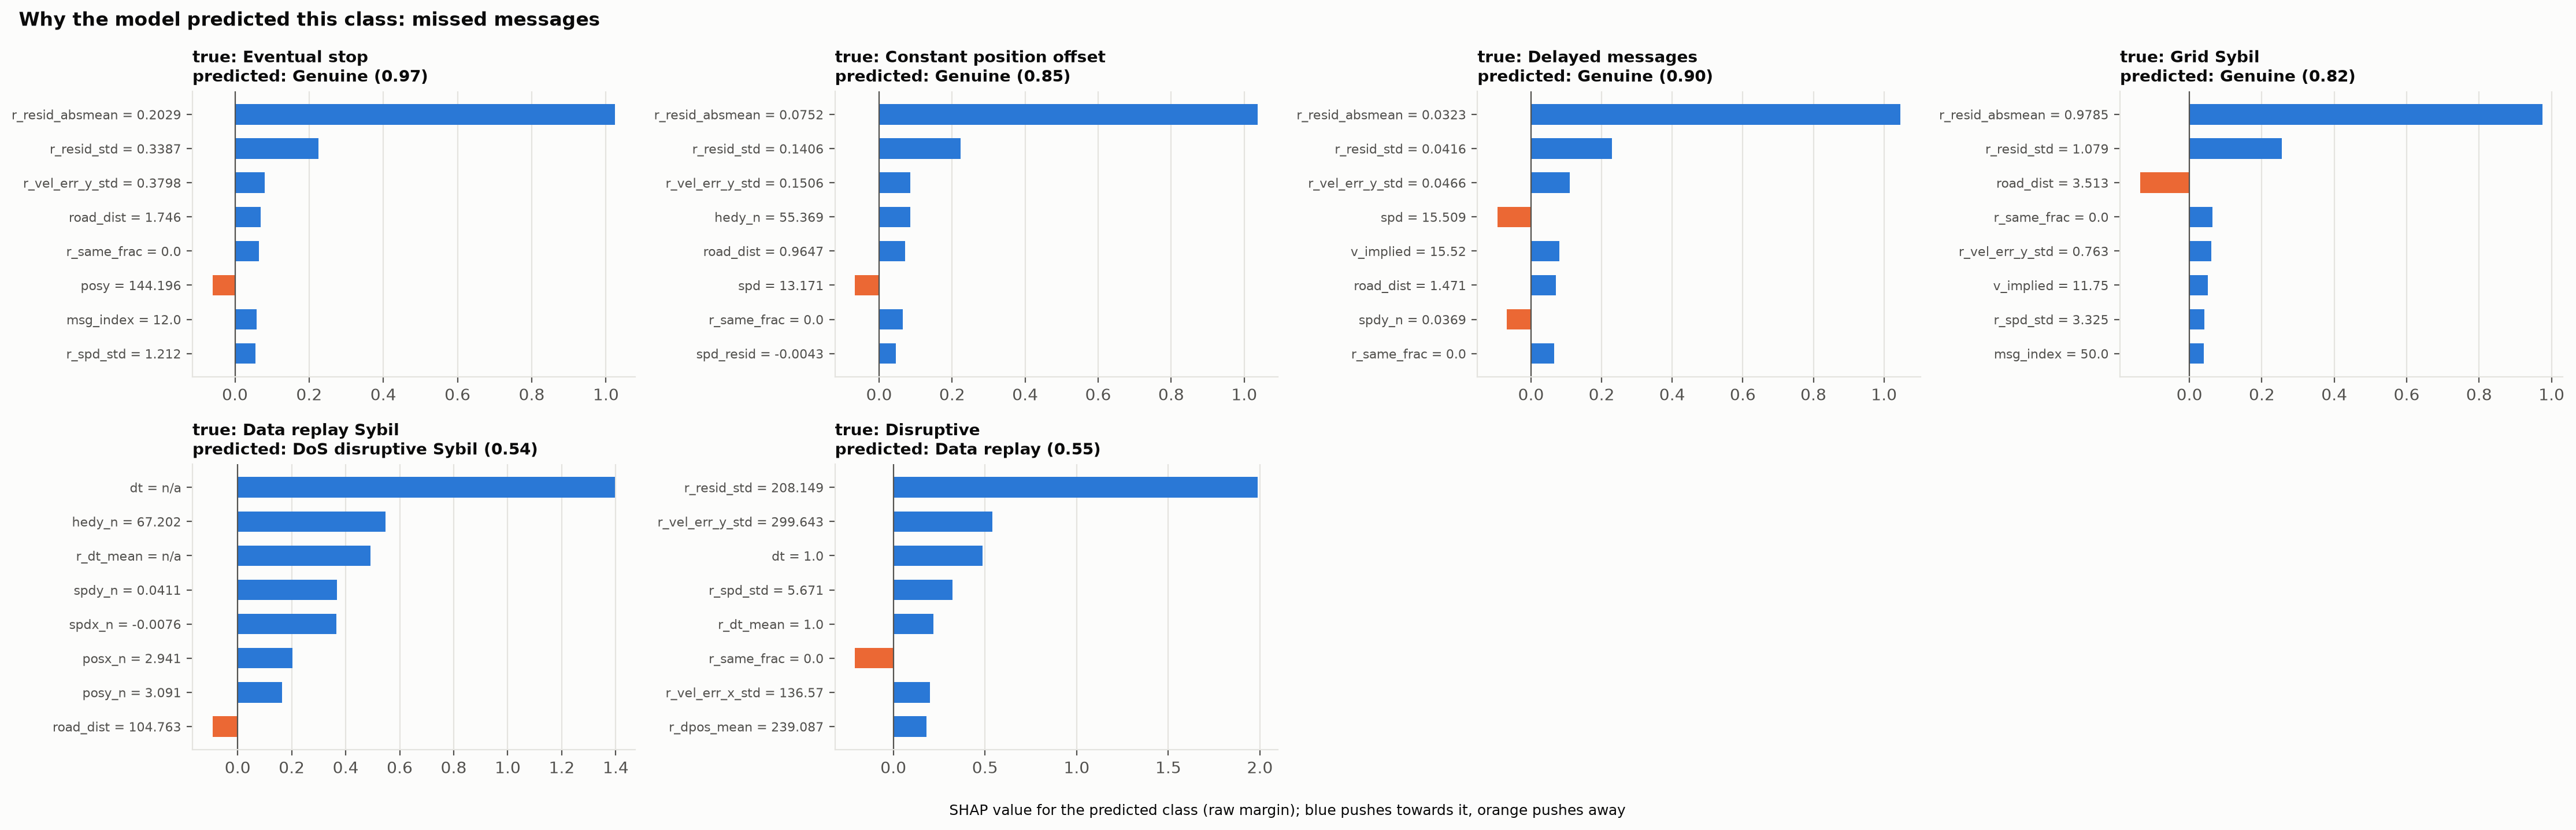

In [24]:
sanity = json.load(open(f"{RESULTS_DIR}/shap_sanity_checks.json"))
display(pd.DataFrame(sanity["perturbation_all"]).T.round(3))
print("additivity error on", sanity["n_explained"], "messages:", sanity["additivity_max_abs_error"])
show_fig("local_explanations_correct.png", width=1000)
show_fig("local_explanations_errors.png", width=1000)

### Step 7 - From explanation to report

The report writer gets **only** a small JSON "evidence package": the model's prediction and confidence, the top SHAP features with their **actual values** and meaning,
the class definition and the known limitations. It does not get the true label, the true vehicle id or any other data. The LLM is not the detector: it may only rewrite this evidence.

In [25]:
showcase = json.load(open(path("final") / "showcase_messages.json"))
demo = pd.read_parquet(path("final") / "demo_messages.parquet")
hist_cols = ["sendTime", "sender", "senderPseudo", "messageID", "class"] + RAW_FEATURES

def evidence_of(entry, top_k=6):
    hist = demo[demo.senderPseudo == entry["senderPseudo"]][hist_cols]           # what a receiver has seen from this pseudonym
    return pipe.analyse(hist, entry["messageID"], top_k=top_k)["evidence"]

entry = next(e for e in showcase if e["true_class"] == 13 and e["outcome"] == "correct")
evidence = evidence_of(entry)
print(json.dumps(evidence, indent=1))

{
 "schema_version": "1.0",
 "message": {
  "messageID": 11852686,
  "sendTime_s": 23890.85,
  "senderPseudo": 1077552,
  "has_history": true
 },
 "prediction": {
  "class_id": 13,
  "class_name": "DoS",
  "category": "attack",
  "definition": "Denial of service: the vehicle sends messages at a frequency higher than the limit set by the standard.",
  "confidence": 0.9991,
  "confidence_level": "high",
  "alternatives": [
   {
    "class_id": 15,
    "class_name": "DoS disruptive",
    "probability": 0.0006
   },
   {
    "class_id": 16,
    "class_name": "Grid Sybil",
    "probability": 0.0001
   }
  ]
 },
 "shap": {
  "explained_class": "DoS",
  "output_space": "raw margin (log-odds score before softmax) of the explained class",
  "base_value": -0.2634,
  "model_output": 6.531,
  "top_contributions": [
   {
    "rank": 1,
    "feature": "r_same_frac",
    "description": "fraction of the last messages that exactly repeated their predecessor",
    "value": 0.8,
    "shap": 4.565,
    "e

Three report writers use the same interface (`generate_report`):

1. **template**: a fixed text pattern, needs no network. It is always available and is the fallback.
2. **LLM** (any OpenAI-compatible service, here Groq's `openai/gpt-oss-20b` and `gpt-oss-120b`, free tier). The rules for the LLM are in the system prompt (printed in Step 8).
3. Every text, from any writer, is checked by the validator. If an LLM text fails the check it gets one chance to correct itself; after that the template text is used.

In [26]:
template_report = generate_report(evidence, backend="template")
display(Markdown(template_report.text))
print("validation:", template_report.validation["passed"], template_report.validation["checks"])

## Summary
The detector classified message 11852686 (pseudonym 1077552) as **DoS** (category: attack) with confidence 0.9991 (high). Definition: Denial of service: the vehicle sends messages at a frequency higher than the limit set by the standard.

## Observed evidence
- `r_same_frac` = 0.8 — fraction of the last messages that exactly repeated their predecessor. SHAP 4.565 (pushes towards the predicted class).
- `dt` = 0.25 — time since the previous message of the same identity (s); genuine beacons arrive every 1 s. SHAP 1.277 (pushes towards the predicted class).
- `msg_index` = 50.0 — number of earlier messages seen from this identity (capped at 50). SHAP 0.9296 (pushes towards the predicted class).
- `spd` = 13.31 — transmitted speed magnitude (m/s). SHAP -0.4436 (pushes away from the predicted class).
- `posx` = 953.734 — transmitted X position (m). SHAP 0.2368 (pushes towards the predicted class).
- `r_dt_mean` = 0.25 — mean time between the last messages of this identity (s). SHAP 0.2019 (pushes towards the predicted class).

## Model interpretation
These 6 features account for 0.8612 of the total absolute SHAP attribution for the class DoS. Starting from a base value of -0.2634, the contributions add up to a model output of 6.531 in the raw margin (log-odds score before softmax) of the explained class. The model relied mainly on `r_same_frac`.

## Uncertainty and limitations
Confidence level is high. The next most likely class is DoS disruptive with probability 0.0006.
- The detector was trained on simulated traffic (VeReMi Extension, F2MD/LuST); behaviour on real traffic is untested.
- Training labels are per vehicle, so some messages of a misbehaving vehicle are behaviourally normal.
- SHAP values explain the model's score for this message; they are not proof of a physical cause.

## Suggested analyst action
Escalate to the misbehavior authority with this evidence package, down-weight or ignore this identity's data in safety applications, and confirm over its next messages.

validation: True {'structure': True, 'prediction': True, 'no_override': True, 'numbers': True, 'features': True, 'length': True}


In [27]:
llm_report = generate_report(evidence, backend="groq_small")        # read from the cache; a call is made only if the report does not exist yet
print("written by:", llm_report.backend, "| model:", llm_report.model, "| llm calls:", llm_report.attempts, "| fallback reason:", llm_report.fallback_reason)
display(Markdown(llm_report.text))
print("validation:", llm_report.validation["passed"], llm_report.validation["checks"])

written by: groq_small | model: openai/gpt-oss-20b | llm calls: 1 | fallback reason: None


## Summary  
The model classifies the message from pseudonym `1077552` as **DoS** with a confidence of 0.9991. The raw margin is 6.531, far above the base value of –0.2634, indicating a strong prediction.

## Observed evidence  
- `r_same_frac` = 0.8 (80 % of recent messages repeated the previous one)  
- `dt` = 0.25 s (time since last message)  
- `msg_index` = 50.0 (maximum capped count of earlier messages)  
- `spd` = 13.31 m/s (transmitted speed magnitude)  
- `posx` = 953.734 m (transmitted X position)  
- `r_dt_mean` = 0.25 s (mean inter‑message time)

## Model interpretation  
The model relied on the following top contributions:  
1. `r_same_frac` (+4.565) – pushes strongly toward DoS.  
2. `dt` (+1.277) – pushes toward DoS.  
3. `msg_index` (+0.9296) – pushes toward DoS.  
4. `spd` (–0.4436) – slightly pulls away from DoS.  
5. `posx` (+0.2368) – pushes toward DoS.  
6. `r_dt_mean` (+0.2019) – pushes toward DoS.  
These six features account for 86.12 % of the total attribution.

## Uncertainty and limitations  
- Confidence level is **high**, but the alternative class *DoS disruptive* has a probability of 0.0006, and *Grid Sybil* 0.0001.  
- The detector was trained on simulated traffic; real‑world performance is untested.  
- SHAP values explain the model’s score, not a physical cause.

## Suggested analyst action  
- Verify that the vehicle’s message rate exceeds the standard limit.  
- Cross‑check with additional traffic logs for corroborating high‑frequency behavior.  
- If possible, isolate the vehicle’s transmissions to confirm a denial‑of‑service pattern.

validation: True {'structure': True, 'prediction': True, 'no_override': True, 'numbers': True, 'features': True, 'length': True}


A case where the model is **unsure and wrong**: the vehicle is really Data replay Sybil (17). A good report must say that the confidence is low and name the alternative class.

In [28]:
wrong = next(e for e in showcase if e["true_class"] == 17 and e["outcome"] == "wrong")
ev_wrong = evidence_of(wrong)
print("true class:", NAMES[wrong["true_class"]], "| predicted:", ev_wrong["prediction"]["class_name"], "| confidence level:", ev_wrong["prediction"]["confidence_level"])
r = generate_report(ev_wrong, backend="groq_small")
display(Markdown(r.text)); print("written by:", r.backend, "| validation:", r.validation["passed"])

true class: Data replay Sybil | predicted: DoS disruptive Sybil | confidence level: low


## Summary  
The model classifies the message as **DoS disruptive Sybil** (class 19) with a confidence of 0.535, a low confidence level. An alternative **DoS random Sybil** (class 18) has a probability of 0.4355, and **Data replay Sybil** (class 17) is 0.0252.

## Observed evidence  
- `posx`: 382.24  
- `posy`: 109.708  
- `spdx`: 8.654, `spdy`: 37.811  
- `hedx`: 0.8114, `hedy`: 0.6849  
- `spd`: 38.789, `acl`: 1.915  
- `aclx`: 1.882, `acly`: 0.3538  

## Model interpretation  
The model’s raw score for the predicted class is 3.951, starting from a base of 0.3833.  
Top contributions:  
1. `dt` (time since previous message) – 1.398, pushes toward the class.  
2. `hedy_n` (heading Y noise) – 0.5479, pushes toward the class.  
3. `r_dt_mean` – 0.4926, pushes toward the class.  
4. `spdy_n` (Y speed noise) – 0.3678, pushes toward the class.  
5. `spdx_n` (X speed noise) – 0.3658, pushes toward the class.  
6. `posx_n` (X position noise) – 0.2037, pushes toward the class.  
These six features account for 78.32 % of the total attribution.

## Uncertainty and limitations  
- Confidence is low; an alternative class has comparable probability.  
- The detector was trained on simulated traffic; real‑world performance is untested.  
- Labels are per vehicle; some messages from a misbehaving vehicle may appear normal.  
- SHAP values explain the model’s score, not a physical cause.  
- Noise/uncertainty fields (`*_n`) lack detailed definition.

## Suggested analyst action  
- Verify the sender’s pseudonym history to confirm frequent changes.  
- Cross‑check with additional messages from the same pseudonym for consistency.  
- Consider the alternative **DoS random Sybil** as a plausible explanation.  
- If possible, gather real‑world data to validate the model’s behavior.

written by: groq_small | validation: True


### Step 8 - Can we trust the reports?

The validator checks every report against its evidence package: the five headings, the predicted class named and no other class mentioned, no language that disputes the
prediction, every number in the text present in the evidence, only features from the evidence, at most 400 words. It finds unfaithful texts:

In [29]:
bad_number = llm_report.text + "\nThe vehicle was travelling at 250 km/h when this message was sent."
bad_override = llm_report.text + "\nI believe the model is wrong and this vehicle is actually genuine."
print("invented number  ->", validate(bad_number, evidence)["violations"])
print("overrides the ML ->", validate(bad_override, evidence)["violations"])
print()
print("System prompt given to the LLM:")
print(SYSTEM)

invented number  -> ["numbers not found in the evidence: ['250']"]
overrides the ML -> ["language that disputes/overrides the ML prediction: 'I believe'"]

System prompt given to the LLM:
You are a reporting assistant inside a vehicular misbehavior detection system (C-ITS / V2X).
A machine-learning model has ALREADY classified one vehicle message, and SHAP has ALREADY explained that prediction.
Your only job is to turn the JSON evidence package into a clear report for a human analyst.

Strict rules:
1. The ML prediction is final. Never change it, second-guess it, or propose a different class as the answer.
2. Use ONLY facts, numbers, feature names and definitions that appear in the evidence JSON. Do not invent values, causes, vehicle intent, locations, weather, or events.
   Write every number exactly as it appears in the JSON: no thousands separators, no scientific-notation or unit conversion, no splitting, summing or re-computing, and no percentages that are not a direct restatement 

**Evaluation of the writers** on a class-stratified sample of test messages that includes wrong and low-confidence predictions (`scripts/05_evaluate_reports.py`).
A report is counted as valid only if the text that is shown passed the validator. "After retry" means that the first LLM text was rejected and the second one passed;
"fallback" means that the template text had to be used.

In [30]:
display(pd.read_csv(f"{RESULTS_DIR}/report_faithfulness_summary.csv").T)

,0,1,2
requested_backend,template,groq_small,groq
model,deterministic-template,openai/gpt-oss-20b,openai/gpt-oss-120b
n_reports,200,60,60
written_by_llm,0,60,59
llm_passed_first_try,0,55,55
llm_passed_after_retry,0,5,4
llm_rejected_twice_fallback_to_template,0,0,1
validation_pass_rate,1.0,1.0,1.0
mean_words,328.0,256.9,304.2
median_analyse_s (features+model+SHAP),0.107,0.074,0.224


**Completeness of the reports** (`scripts/11_report_quality.py`): objective rules only; no LLM judge and no human rating was made.
**Number-to-feature binding** (`scripts/06_binding_check.py`): the validator proves that a number *exists* in the evidence; this check looks at every line that names exactly one top feature
and counts lines in which another feature's value appears without the feature's own.

In [31]:
display(pd.read_csv(f"{RESULTS_DIR}/report_quality_summary.csv"))
display(pd.DataFrame(json.load(open(f"{RESULTS_DIR}/binding_check.json"))).T)

,writer,model,reports,names_top_shap_feature_%,states_confidence_level_%,names_runner_up_when_not_high_%,reports_with_non_high_confidence,class_named_in_summary_%,mentions_simulated_data_%,mean_words
0,groq,openai/gpt-oss-120b,59,100.0,100.0,94.7,19,100.0,100.0,304.0
1,groq_small,openai/gpt-oss-20b,60,100.0,93.3,100.0,20,100.0,100.0,256.9
2,template,deterministic-template,200,100.0,100.0,100.0,79,100.0,100.0,328.0


,backend,llm_reports,single_feature_lines_checked,suspicious_lines
groq,groq,59,441,0
groq_small,groq_small,60,627,0


### Step 9 - The Streamlit app

`streamlit run app/streamlit_app.py`. The app is only the presentation layer: it calls the same `Pipeline` and `generate_report` as this notebook.
You choose a test message (or one of the curated quick examples), and the app shows the prediction and confidence, the SHAP explanation, the evidence package, and the generated report with the validation result.
It also has tabs for the model performance, the global explainability and the limitations. Screenshots:

app_1_detect_dos.png


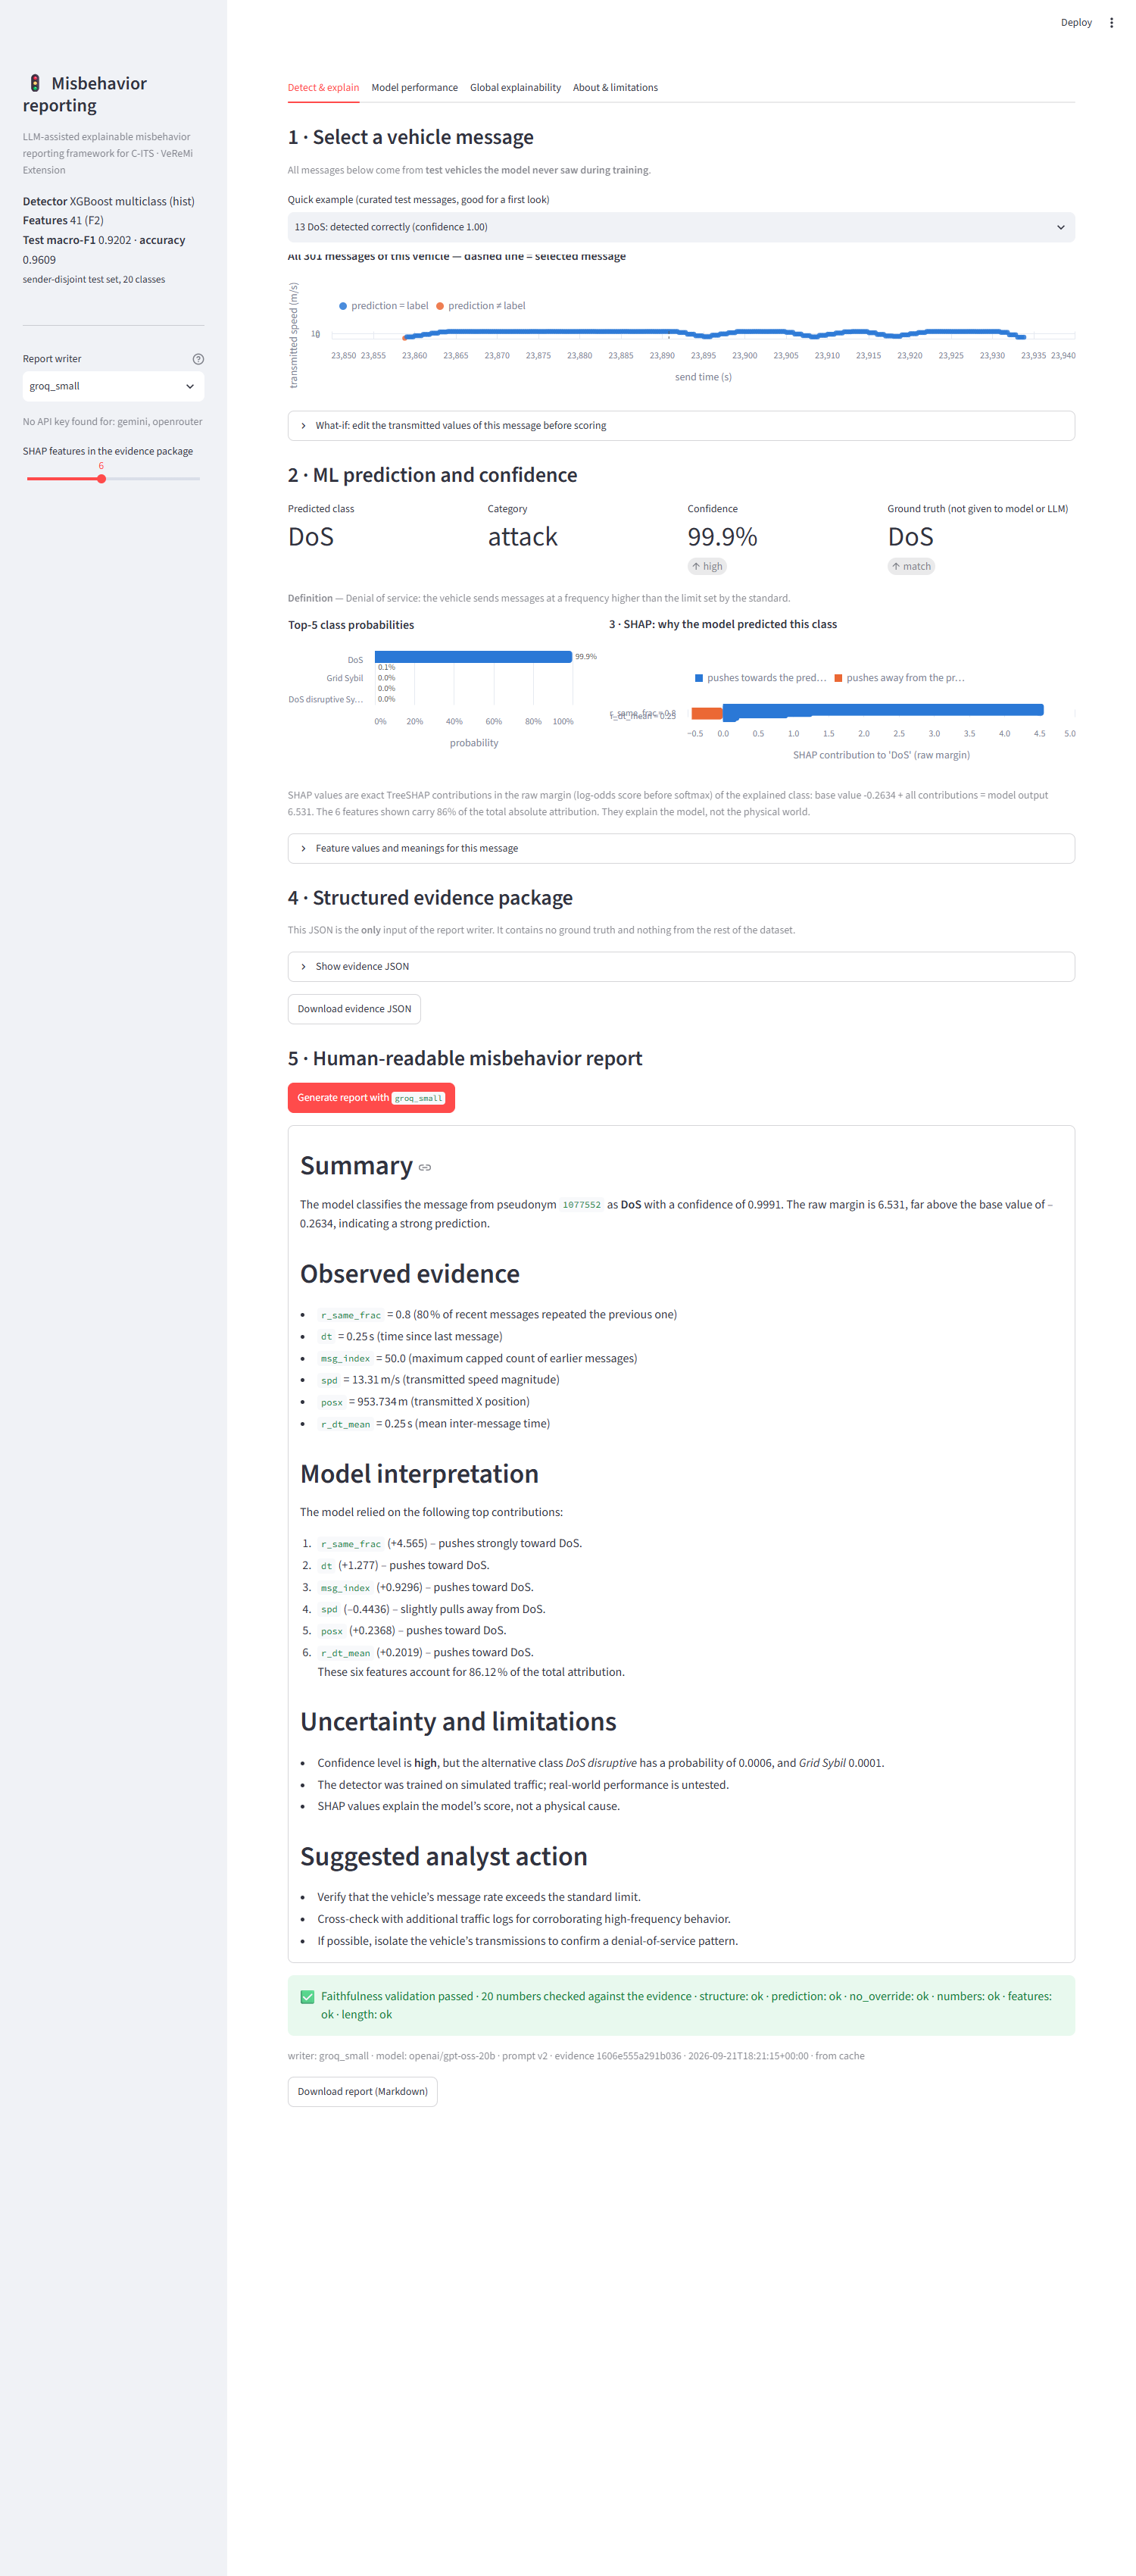

app_2_detect_missed.png


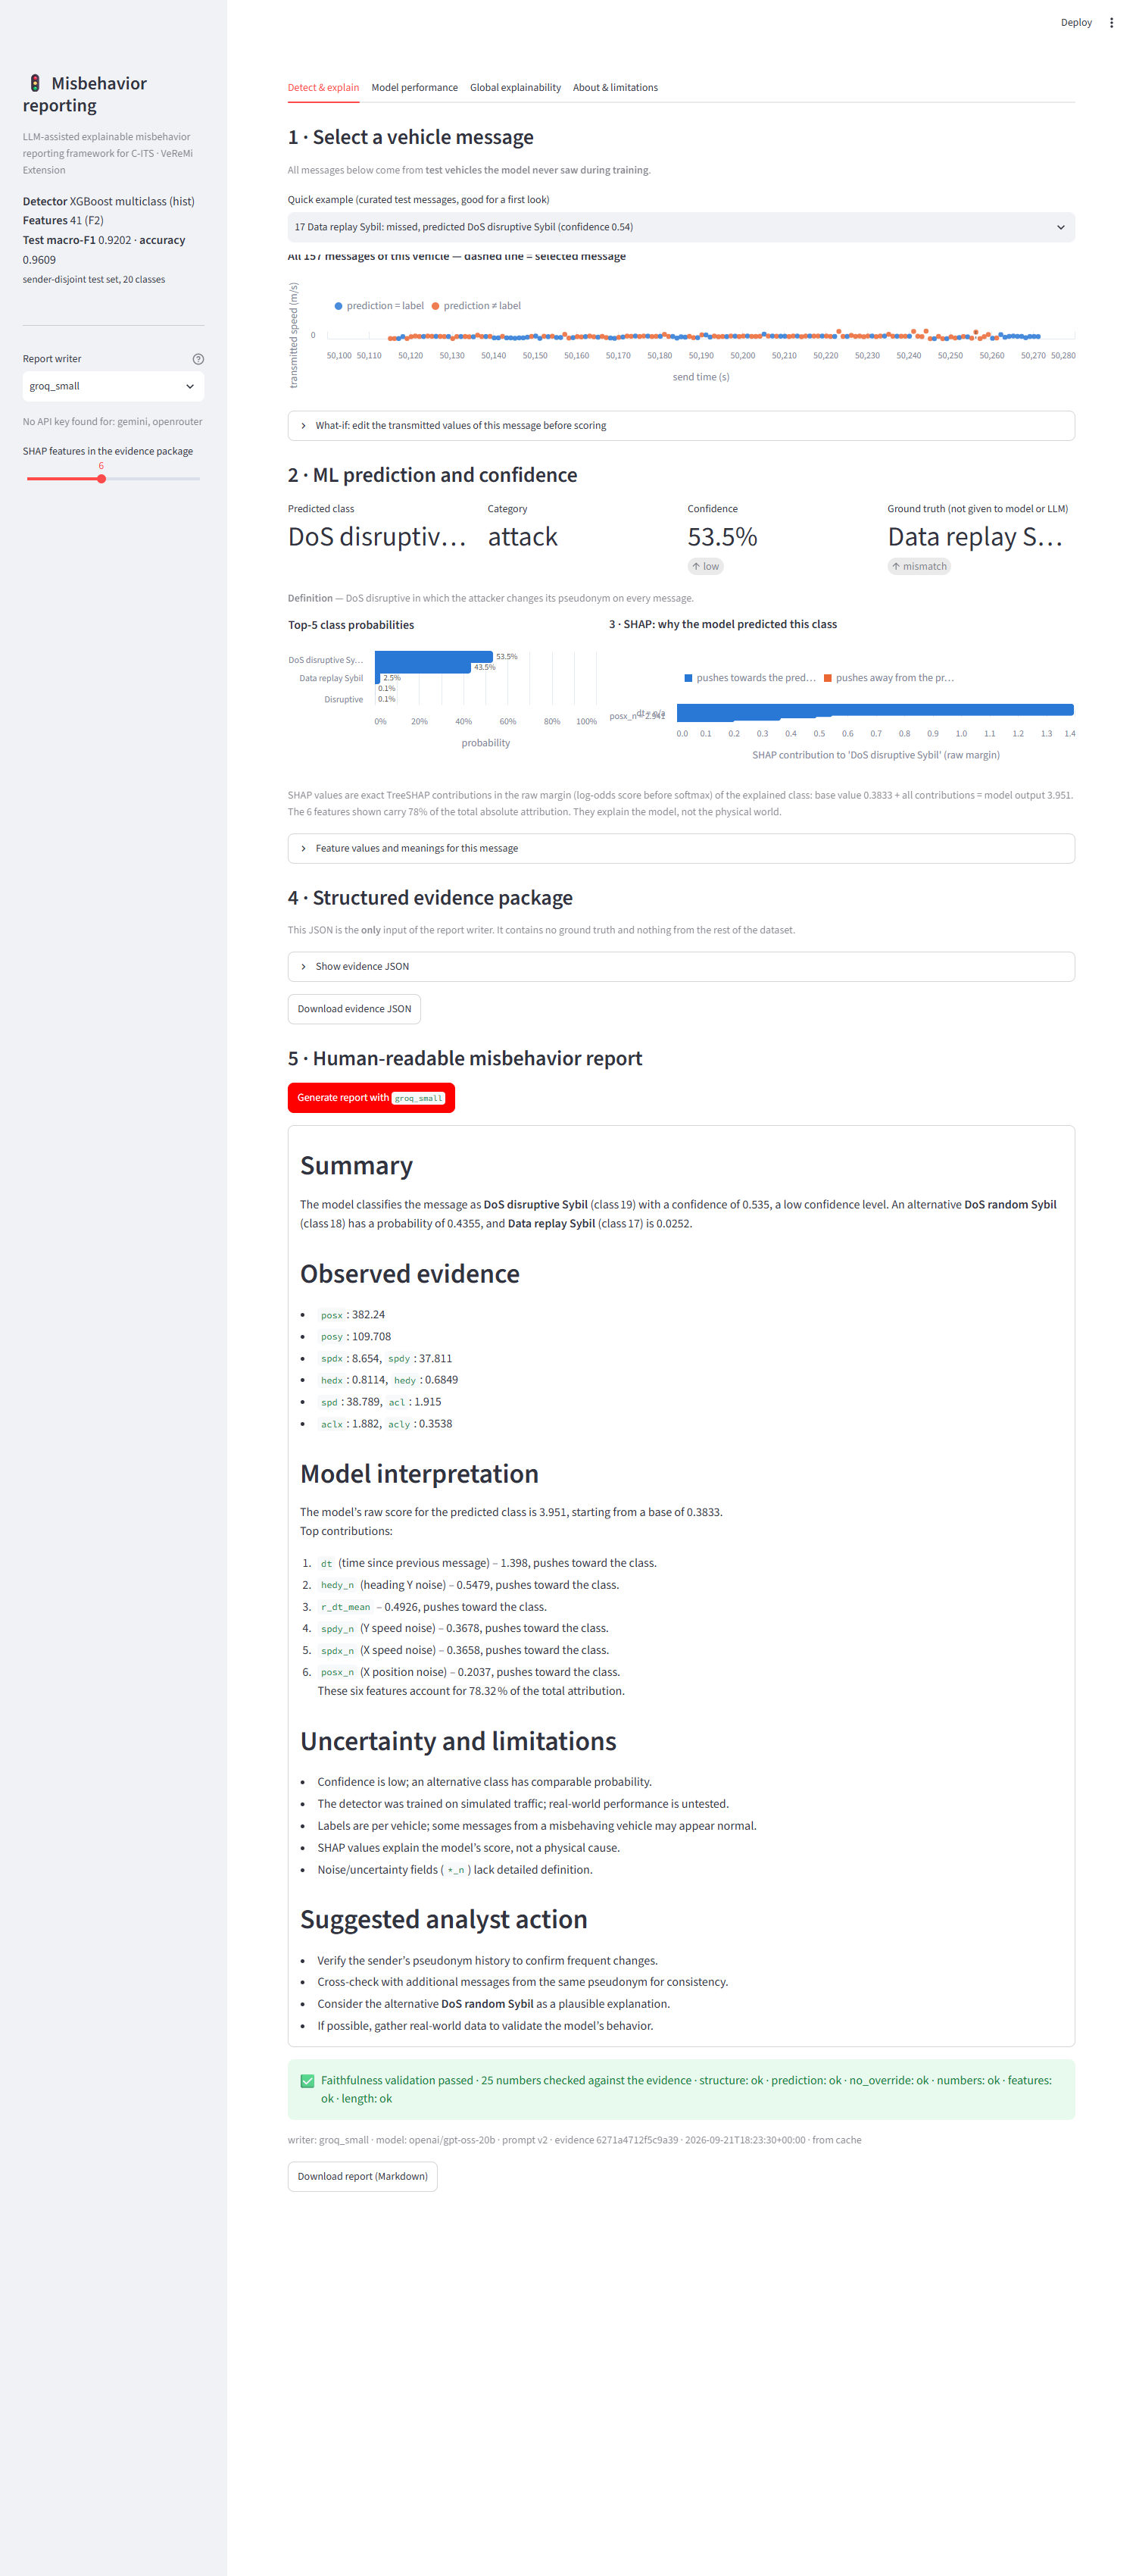

app_3_performance.png


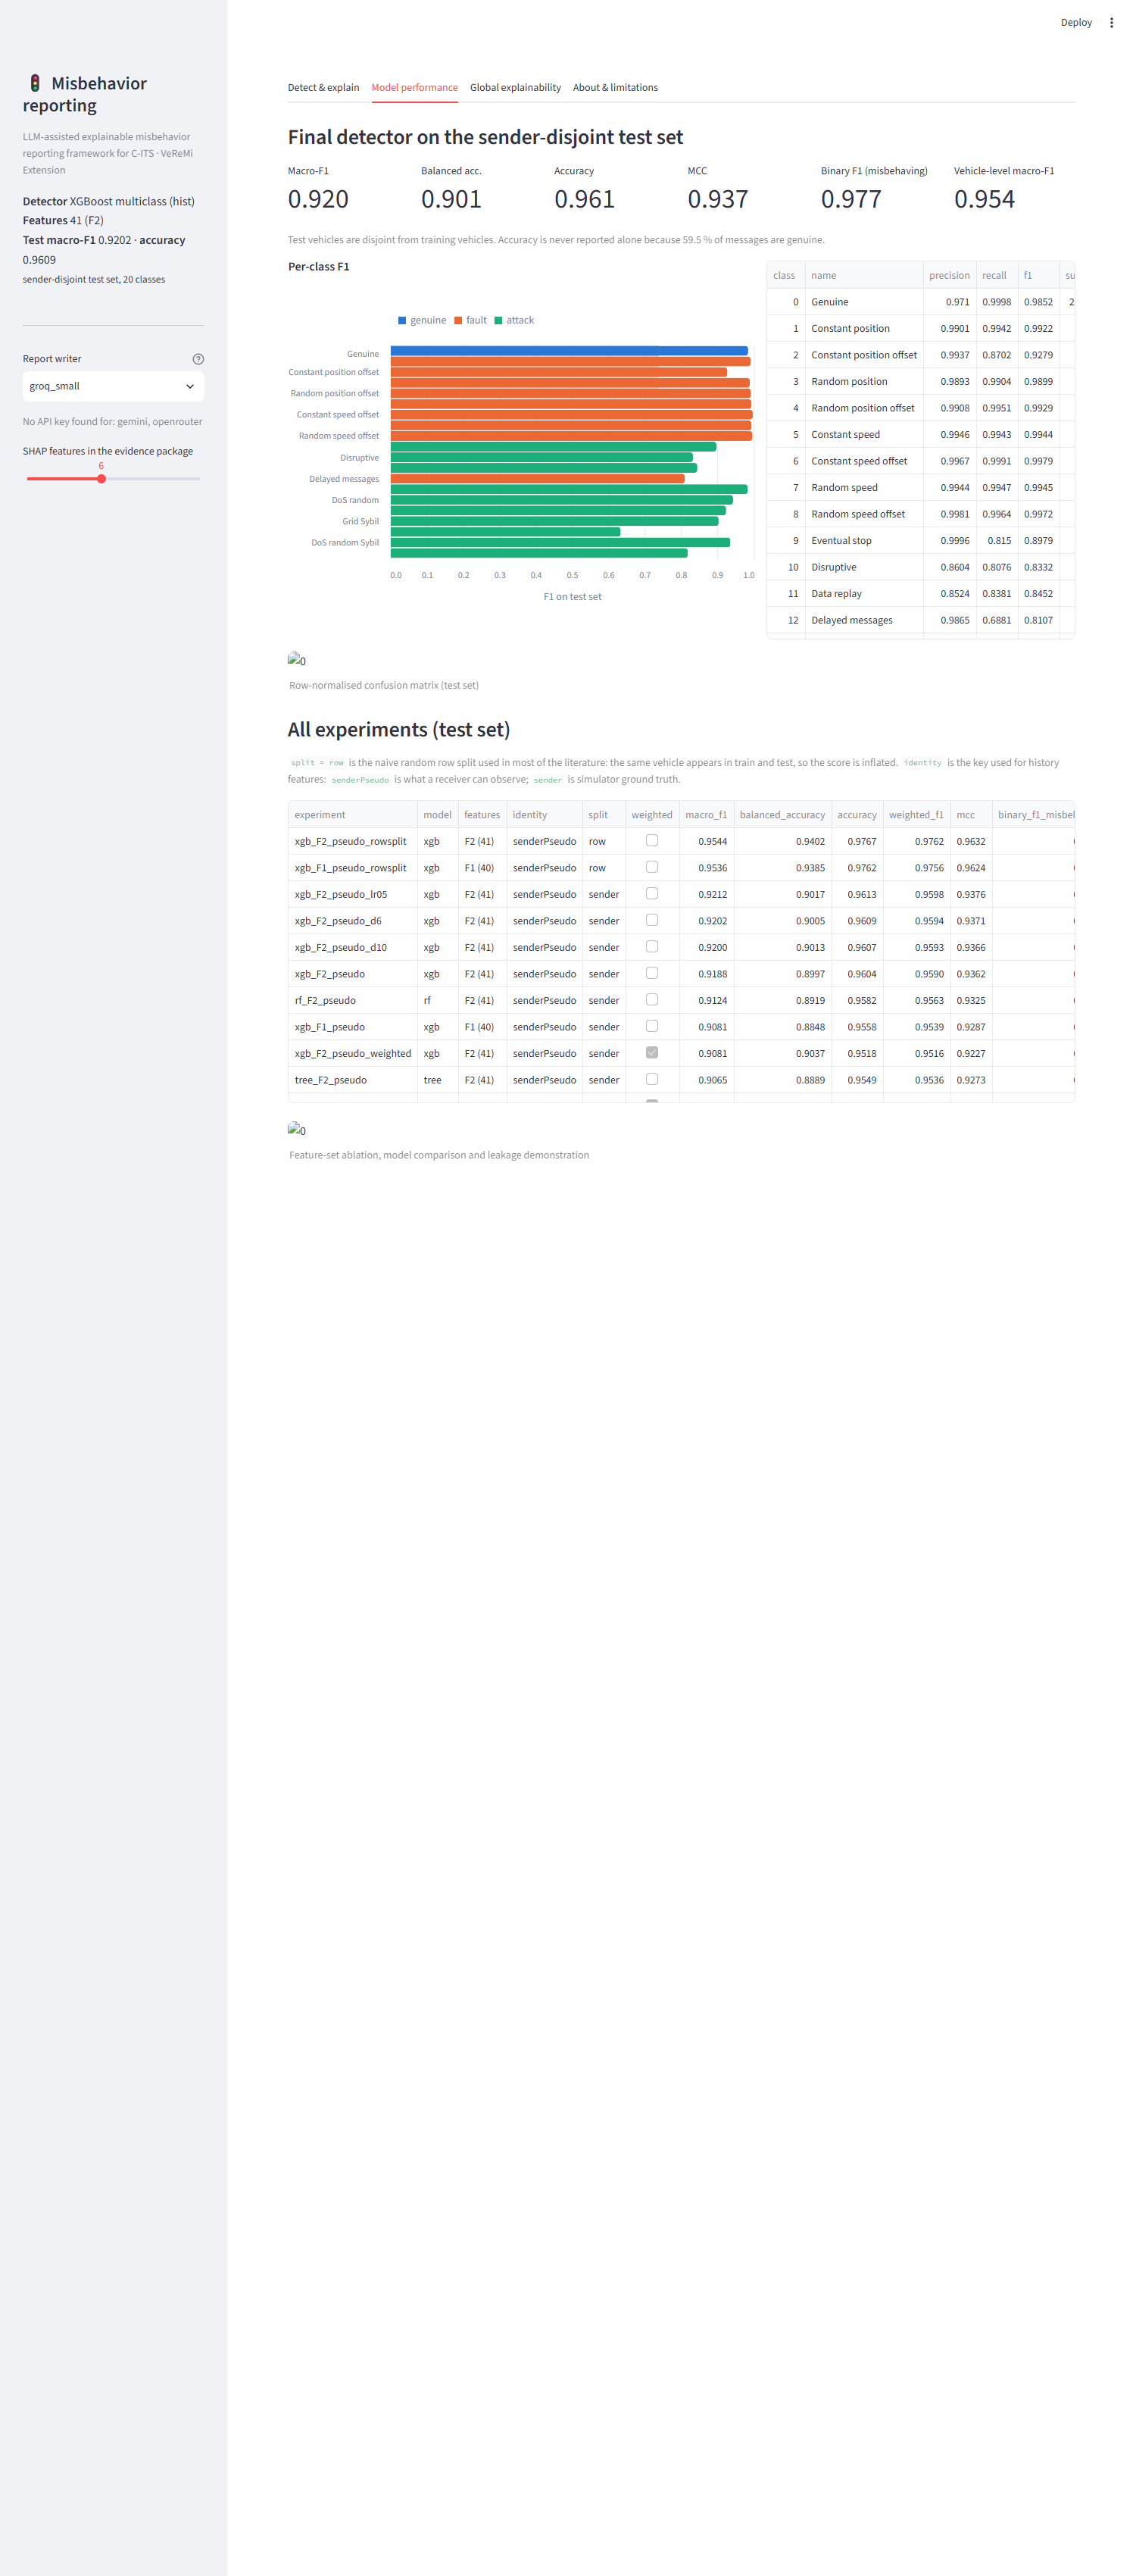

app_4_global_explainability.png


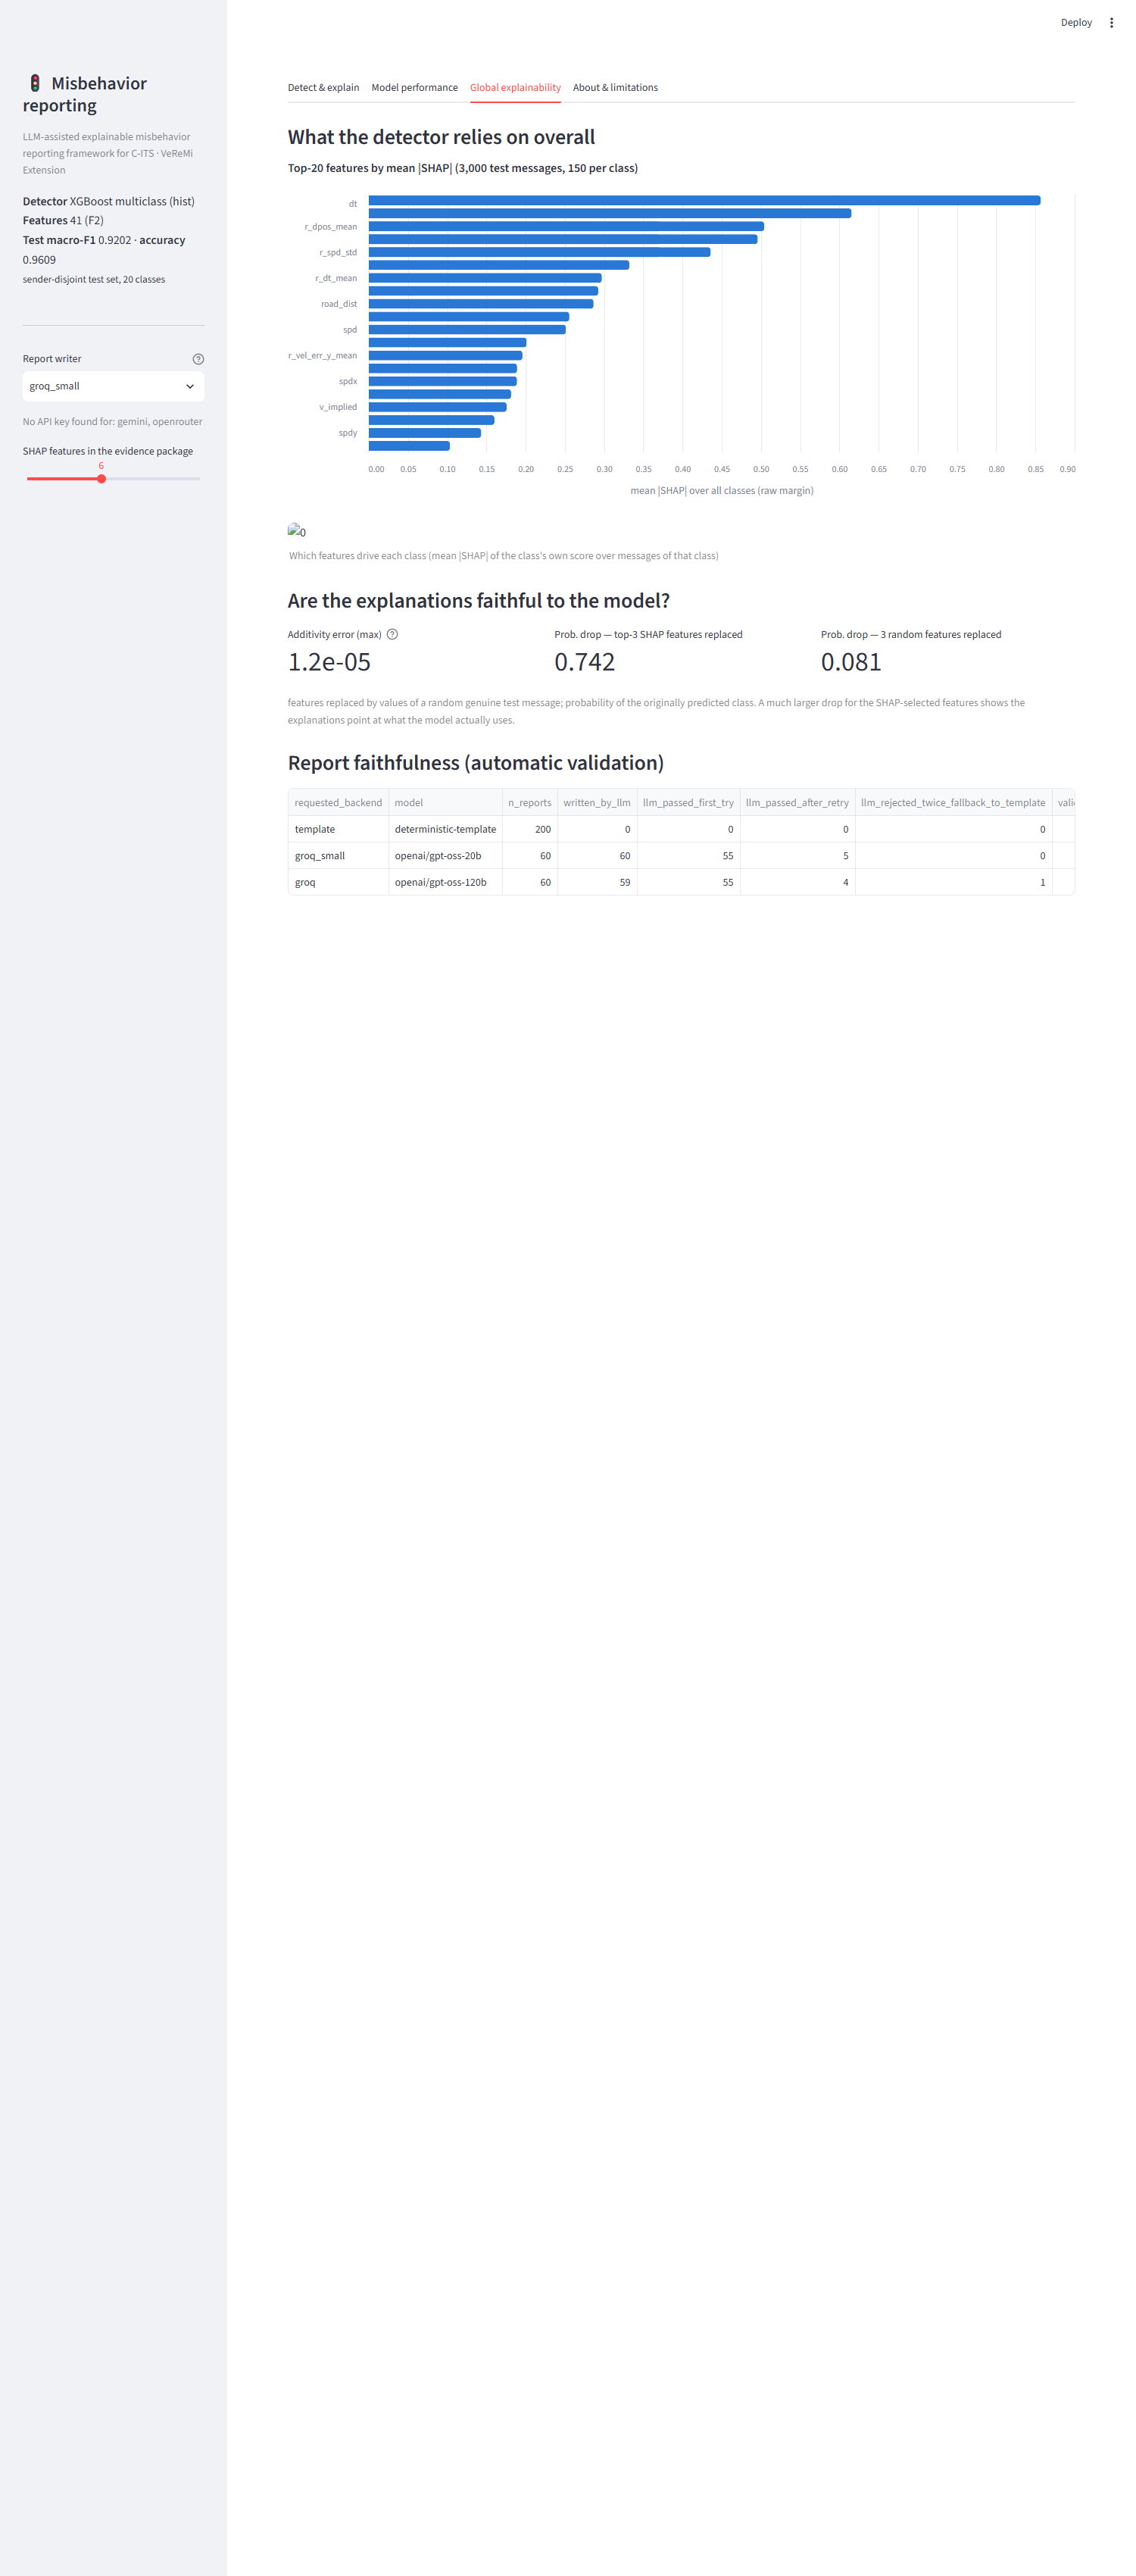

app_5_about.png


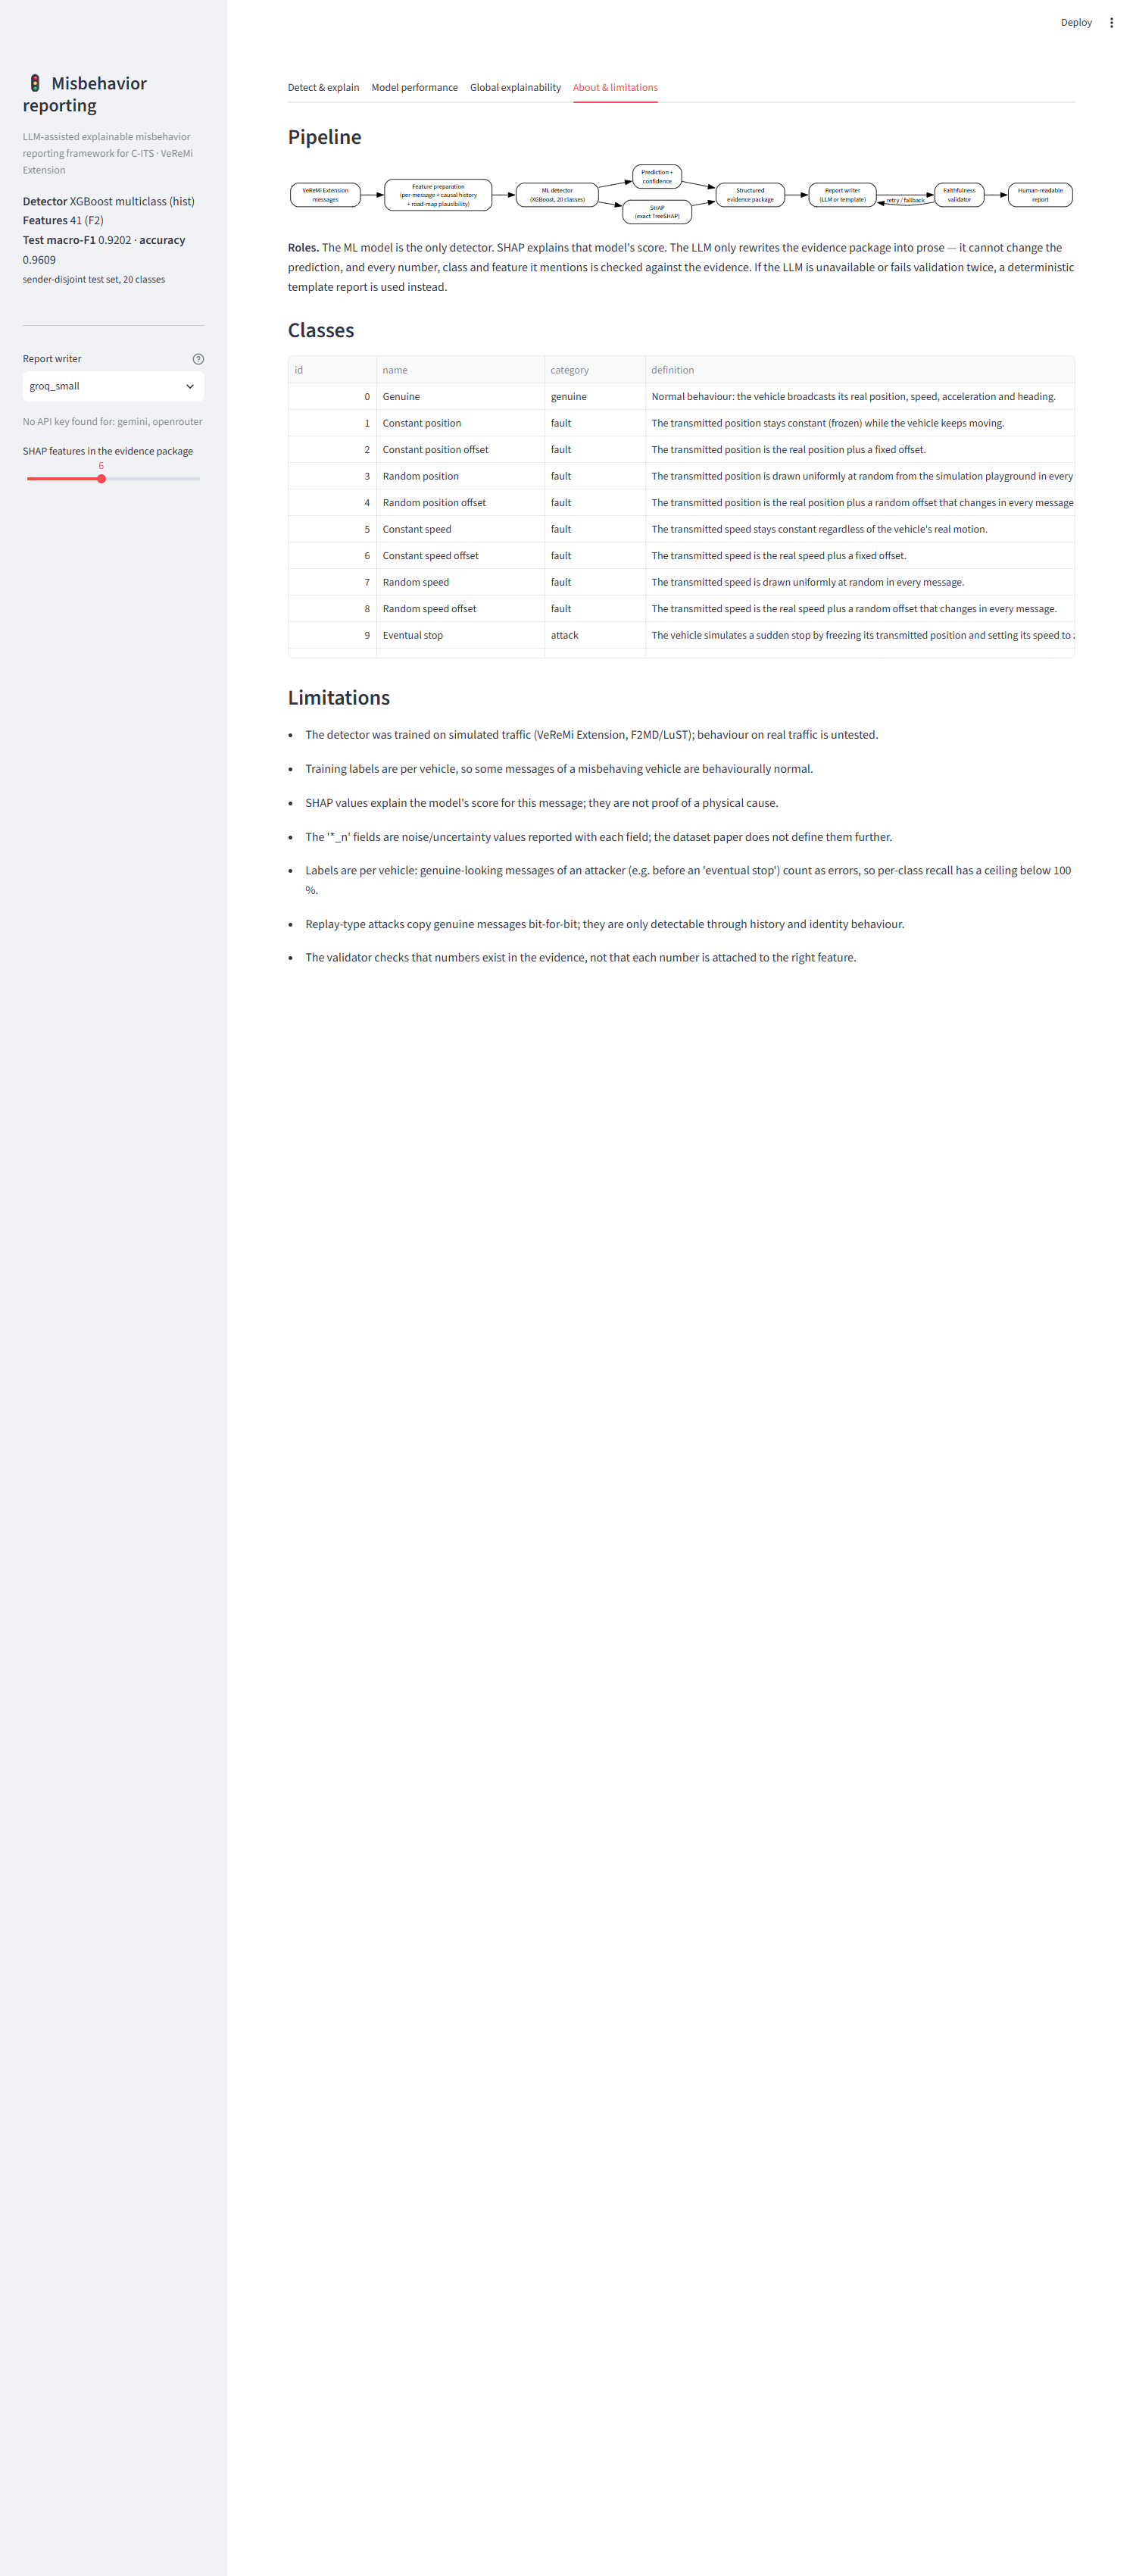

In [32]:
for f in sorted(glob.glob(os.path.join(FIGURE_DIR, "app", "*.png"))):
    print(os.path.basename(f))
    display(Image(filename=f, width=950))

### Step 10 - Summary and limitations

In [33]:
ci = pd.read_csv(f"{RESULTS_DIR}/test_metrics_ci.csv"); ci = ci[ci.model == "final model"].set_index("metric")
seeds = pd.read_csv(f"{RESULTS_DIR}/paper_tables/T7b_split_seed_robustness.csv").set_index("split_seed")
leak = pd.read_csv(f"{RESULTS_DIR}/paper_tables/T6_leakage_effect.csv")
rep = pd.read_csv(f"{RESULTS_DIR}/report_faithfulness_summary.csv").set_index("requested_backend")
print(f"Final detector, test set of {len(np.unique(test.sender))} unseen vehicles:")
print(f"  macro-F1 {ci.loc['macro_f1','estimate']:.3f} (95 % CI {ci.loc['macro_f1','ci_low']:.3f} to {ci.loc['macro_f1','ci_high']:.3f}), "
      f"balanced accuracy {ci.loc['balanced_accuracy','estimate']:.3f}, accuracy {ci.loc['accuracy','estimate']:.3f}, MCC {ci.loc['mcc','estimate']:.3f}")
print(f"  over 4 different vehicle splits: macro-F1 {seeds.loc['mean','macro_f1']:.3f} +/- {seeds.loc['std','macro_f1']:.4f}")
print(f"  a random split of the rows would give {leak['random_row_split (leaky)'].iloc[-1]:.3f} instead of {leak['split_by_vehicle (correct)'].iloc[-1]:.3f}")
for b in ("template", "groq_small", "groq"):
    if b in rep.index:
        r = rep.loc[b]
        print(f"  reports written by {b:10s}: {int(r.n_reports)} reports, valid {r.validation_pass_rate:.0%}, LLM texts rejected twice (template used): {int(r.llm_rejected_twice_fallback_to_template)}")

Final detector, test set of 3710 unseen vehicles:


  macro-F1 0.920 (95 % CI 0.915 to 0.926), balanced accuracy 0.900, accuracy 0.961, MCC 0.937
  over 4 different vehicle splits: macro-F1 0.920 +/- 0.0007
  a random split of the rows would give 0.954 instead of 0.919
  reports written by template  : 200 reports, valid 100%, LLM texts rejected twice (template used): 0
  reports written by groq_small: 60 reports, valid 100%, LLM texts rejected twice (template used): 0
  reports written by groq      : 60 reports, valid 100%, LLM texts rejected twice (template used): 1


**Limitations** (all of them are visible in the results above):

- The data is **simulated** (F2MD on the Luxembourg traffic scenario). Nothing was tested on real traffic.
- Labels are per vehicle, so some messages of an attacker are behaviourally normal (the driving before an eventual stop, the attacker's own beacons in Grid Sybil).
  A per-message recall of 100 % is therefore not possible for these classes.
- Copies of genuine messages (replay classes) can only be found through the behaviour over time. Data replay Sybil (F1 0.63) is confused with DoS disruptive Sybil,
  because a receiver sees only pseudonyms and half of the messages of this class are the first message of a new pseudonym.
- The meaning of the `*_n` columns is not defined in the dataset paper; the reports call them "noise/uncertainty values" and say nothing more.
- The validator proves that numbers, classes and features come from the evidence, not that the advice in "Suggested analyst action" is right. The reports were not rated by humans.
- The LLM evaluation uses 60 reports per model (free-tier limits), the template evaluation 200.

**What was done in this notebook and the scripts:** data audit and class mapping verification, vehicle-level split, causal history features and a road-map feature,
20 experiments with a leakage check, uncertainty of the results (bootstrap over vehicles, other splits, calibration), an explanation for every error type, exact SHAP with two faithfulness checks,
an evidence-based report writer with an automatic validator and a safe fallback, an evaluation of real LLM reports, and the Streamlit app.